# LSN-1.6 — Data Requirements, Limitations & the Pre-Sales Question Bank

| | |
|---|---|
| **Lesson** | `LSN-1.6` — Module `MOD-1` (ML Literacy), Weeks 1–2 · **the last lesson of the module** |
| **Serves** | `OUT-1.6` — *articulate data requirements and ML limitations ("no data, no model; it can only infer so far") and run the pre-sales question bank* |
| **Duration** | 60 min live session (20 checklist · 25 case walkthrough · 15 question-bank workshop) + 30 min pre-work |
| **Verified by** | `ASM-1` — the async quiz **and** the live mock pre-sales conversation (Vlad or Dorel plays the client) |
| **Homework** | **Yes.** Apply the refined bank to one prospect you know first-hand. The filled bank is `ASM-1` evidence for `OUT-1.6` |
| **Lesson plan** | `program/lessons/LSN-1.6-data-requirements-presales-question-bank.md` |

**Timing check:** 20 + 25 + 15 = 60 min = the 1 h contract duration. ✓

**The sentence this hour exists to make useful.** Vlad, on what he carried out of 6MAP: *"I need data in order
for the model — it was a truism, but it's the truth. It can only infer to a certain point."* Everybody nods at
that sentence. Then a deal wobbles four weeks in because nobody asked **how many examples of the rare thing**
before the SOW was signed. This hour turns the truism into five questions you ask in the first meeting.

**What is new here, and what is not.** Nothing in this lesson is a new ML concept. `LSN-1.1` gave you the five
jobs, `LSN-1.2` inputs and outputs, `LSN-1.3` how to grade a model, `LSN-1.4` a network you trained yourself,
`LSN-1.5` the words for it. **This hour is the commercial skill**: the five checks that decide whether a
project is real, the walkthrough that runs them on a live prospect, and the question bank you take into
`ASM-1`.

**The number this lesson opens on is yours.** In `LSN-1.4` you trained the same architecture on 10, 100, 200,
1,000, 10,000 and 60,000 labelled examples and watched accuracy go **23.88% → 53.38% → 64.41% → 84.23% →
92.77% → 97.04%**. That curve is the answer to *"how much data do we need?"* — and you produced it. Segment 1
re-plots it from your own pinned numbers.

### What this notebook is

Not a lab and not a checkpoint battery — this is a **live workshop**. The notebook is three things:

1. **your pre-work** — the case-brief instruction, the starter bank to mark up, and the cell where your one
   data-reality risk and your one bank edit get written down *before* the session;
2. **the companion to the live hour** — the five checklist rows with a number attached to each, three small
   seeded demos that make "labelled", "enough" and "fresh" physical, and the five-step case walkthrough with
   space to capture what the room says;
3. **the homework template** — the blank question bank, one block per checklist dimension, with an advisor
   that pre-checks your answers against the pass bar before you submit them.

### How to run this

1. Kernel: the repo `.venv` (Python 3.12). From the repo root:
   `.venv/bin/jupyter notebook notebooks/lessons/LSN-1.6_Data_Requirements_Presales_Question_Bank.ipynb`
2. `Run → Run All Cells`. **Total runtime is a few seconds** — three tiny scikit-learn fits, nothing else.
   Every number this notebook prints, it computed; every number it *quotes* from `LSN-1.4` is pinned by an
   assert that fails loudly if it drifts.
3. Fill in the four cells that ask you to: **pre-work** (before the session), the **walkthrough capture** and
   the **refined bank** (during the live hour), and the **homework template** (before `ASM-1`). None of them
   ever crash when empty — they tell you what is still missing.
4. Your saved answers land in `outputs/lsn-1.6/`, which is gitignored. They stay on your machine.

> ### `[GAP-5 — pending Vlad/Dorel case brief]`
>
> The anonymized construction-site case brief is a **build item owned by Vlad and Dorel** (`GAP-5` in the
> module spec) and **it does not exist yet.** The lesson plan was written so the walkthrough *"runs even
> before the GAP-5 brief lands"*, and this notebook is built the same way: **every place the brief's facts
> belong is marked with this banner.** Where the walkthrough needs a concrete number to teach with, the number
> is either (a) one you produced yourself in `LSN-1.4`, or (b) explicitly labelled a **hypothetical
> placeholder** the brief will replace. **Nothing in this notebook is presented as a fact about the real
> prospect.** If you are reading this after the brief has landed, the walkthrough sections are where its
> numbers slot in.

## Setup — imports, palette, and the four rules this notebook obeys

- **Everything is seeded, everything is CPU, nothing is trained twice.** Three scikit-learn fits, one seeded
  generator, no torch (`SI-3`). Two executions produce byte-identical output — which is the only way a
  committed notebook can be quoted in a client conversation.
- **The demos are props, and the props are labelled.** The site-photo world in segments 1 and 2 is **synthetic
  data with six made-up numeric columns**. It is not a construction dataset, it does not contain any client's
  photos, and no number it produces is evidence about any real project. What it *is* good for: showing the
  *shape* of a failure — two honest people disagreeing about a label, a model inheriting one of them, a model
  staying confident after the world moved. `LSN-1.5`'s convention, kept: a prop is a prop, out loud.
- **The only numbers with authority here are the ones you trained.** The `LSN-1.4` degradation curve is quoted,
  not re-run, and pinned by asserts against that notebook's executed output. Re-training it would take minutes
  and prove nothing new.
- **No LLM libraries** (`SI-24a`), no `DataFrame.style` (`LL-33`), no measured wall-clock printed (`LL-24`),
  no warnings emitted (`SI-28b`). Cross-cell values are named in CAPS, because `_`-prefixed names are
  IPython's input history and would silently become the previous cell's source text (`LL-41`).

In [1]:
# numpy (the synthetic site-photo world, the curve arithmetic)
import numpy as np
# pandas (five tables: the checklist scoreboard, the label-cost ladder, the failure map, the bank)
import pandas as pd
# matplotlib (four figures: the degradation curve, label agreement, staleness, bank coverage)
import matplotlib.pyplot as plt
# scikit-learn: two tiny logistic fits + Cohen's kappa. Nothing here is a model we would ship (SI-24)
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, cohen_kappa_score
# stdlib re (word-boundary probes for the homework advisor - LL-30: "own" must not match "downtown")
import re
# stdlib textwrap (the advisor prints wrapped paragraphs, not 200-character lines)
import textwrap
# stdlib json / getpass / datetime (the four artifacts this notebook saves to outputs/)
import json
import getpass
from datetime import datetime, timezone
# stdlib pathlib (locate the repo root without hardcoding paths - SI-5)
from pathlib import Path

# --- VSP palette. Four data colours from the design system + one ink colour for reference lines,
# --- cell edges and annotation text (VSP navy-darkest), plus two darker tints used only where
# --- annotation text must stay readable at projector size.
VSP = {
    "navy":   "#59709c",  # navy-light      - the plain / baseline series
    "green":  "#65a74e",  # green           - anything that worked
    "yellow": "#ffe86b",  # yellow          - anything highlighted
    "mint":   "#97f377",  # green-lightest  - third series
    "ink":    "#2b374d",  # navy-darkest    - lines, edges, text
    "green_dark": "#4f813e",
    "gold_dark":  "#d9b800",
}

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.edgecolor": VSP["ink"],
    "axes.labelcolor": VSP["ink"],
    "text.color": VSP["ink"],
    "xtick.color": VSP["ink"],
    "ytick.color": VSP["ink"],
    "legend.frameon": False,
})
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 24)
pd.set_option("display.max_colwidth", 96)


def find_repo_root(start: Path) -> Path:
    """Walk up from `start` to the directory holding src/ and README.md (mirrors src/utils/pathing.py)."""
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "src").is_dir() and (candidate / "README.md").is_file():
            return candidate
    raise ValueError("Repo root not found - are you running inside the VSP-AI-ML-Training clone?")


REPO_ROOT = find_repo_root(Path.cwd())
OUT_DIR = REPO_ROOT / "outputs" / "lsn-1.6"          # gitignored via outputs/lsn-*/ (SI-4)

# ---------------------------------------------------------------- the pins
SEED = 16_042          # lesson 1.6, run 042. One seed for the whole notebook.
np.random.seed(SEED)   # belt and braces; every draw below uses its own explicit generator

# ---- THE LSN-1.4 DEGRADATION CURVE. Quoted from that notebook's executed output cells, not
#      remembered and not re-trained: (labelled examples, accuracy at 3 epochs, accuracy at equal
#      compute ~471 gradient steps). Held-out test set: the same 10,000 MNIST digits every time.
CURVE = [(10, 0.2388, 0.3486),
         (100, 0.5338, 0.7563),
         (200, 0.6441, 0.8290),       # <- the client point LSN-1.4 TRAINED rather than interpolated
         (1_000, 0.8423, 0.8846),
         (10_000, 0.9277, 0.9277),    # <- the lab model everybody built
         (60_000, 0.9704, 0.9704)]    # <- the same architecture on all the data
CURVE_N = [n for n, _a, _b in CURVE]
GUESSING = 0.10                        # 10 classes, so a coin-flip model scores 10%
LAB_ACC = 0.9277                       # the lab model, on 10,000 held-out digits
FULL_ACC = 0.9704                      # all 60,000 labelled examples, same architecture
CLIENT_200 = 0.6441                    # "we have about 200 labelled photos"
CLIENT_200_HARD = 0.8290               # ... trained to equal compute (40x the epochs)
RARE_EVENT_N = 40                      # the lesson plan's number in the "Enough" row


# ---------------------------------------------------------------- shared helpers
def wrap(label: str, text: str, width: int = 104, pad: int = 12) -> None:
    """Print `label` + wrapped `text` in the answer-key idiom used across this programme."""
    print(textwrap.fill(text, width=width, initial_indent=f"  {label:<{pad - 2}}",
                        subsequent_indent=" " * pad))


def rule(title: str = "", width: int = 104) -> None:
    """A section rule for long printed outputs."""
    print("=" * width)
    if title:
        print(title.center(width))
        print("=" * width)


def probe_regex(pattern: str) -> str:
    """A pattern ending in '*' matches a word STEM; otherwise it must match a whole word/phrase.

    LL-30: naive substring probes fire on the wrong words - "own" inside "downtown", "old"
    inside "gold", "only" inside "commonly". Word boundaries fix it.
    """
    p = pattern.strip().lower()
    stem = p.endswith("*")
    if stem:
        p = p[:-1]
    body = r"\s+".join(re.escape(w) for w in p.split())
    return r"\b" + body + ("" if stem else r"\b")


def probe(text, patterns) -> list:
    """Which of `patterns` appear in `text`, matched on word boundaries."""
    t = " ".join(str(text).lower().split())
    return [p for p in patterns if re.search(probe_regex(p), t)]


def probe_spans(text, patterns) -> list:
    """The DISTINCT words of `text` that any pattern matched (LL-35: count words, not patterns)."""
    t = " ".join(str(text).lower().split())
    raw = sorted({(m.start(), m.end()) for p in patterns
                  for m in re.finditer(probe_regex(p), t)}, key=lambda s: (s[0], -s[1]))
    words, end = [], -1
    for a, b in raw:
        if a >= end:
            words.append(t[a:b])
        end = max(end, b)
    return words


def show(frame: pd.DataFrame) -> None:
    """Display a PLAIN DataFrame.

    Deliberately NOT `DataFrame.style`: a Styler stamps a random uuid into its HTML and a live
    memory address into its text/plain repr, so two executions of this notebook would differ
    byte-for-byte for no reason at all (LL-33). Formatting happens before the frame is built.
    """
    display(frame)


def save_artifact(name: str, payload: dict) -> Path:
    """Write one gitignored per-participant artifact and return its path (SI-4)."""
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    path = OUT_DIR / f"{name}_{getpass.getuser()}.json"
    path.write_text(json.dumps({"lesson": "LSN-1.6", "serves": ["OUT-1.6"], "assessment": "ASM-1",
                                "user": getpass.getuser(),
                                "timestamp_utc": datetime.now(timezone.utc)
                                .strftime("%Y-%m-%d %H:%M UTC"), **payload}, indent=2))
    return path


# --- Self-tests on the probe helpers. Every one of these is a real false positive that
#     word-boundary matching prevents (LL-30/LL-35), using this lesson's own vocabulary.
assert probe("we walked downtown", ["own*"]) == []
assert probe("who owns the drone footage", ["own*"]) == ["own*"]
assert probe("the gold standard label", ["old"]) == []
assert probe("how old is the data", ["old"]) == ["old"]
assert probe("commonly misread", ["only"]) == []
assert probe("only 40 examples", ["only", "example*"]) == ["only", "example*"]
assert probe_spans("no labels, no label cost", ["label*", "labels"]) == ["labels", "label"]

# --- The curve, pinned. If any of these drifts, this lesson is quoting a number LSN-1.4 no
#     longer produces, and the assert is how you find out (SI-17).
assert [n for n, _a, _b in CURVE] == [10, 100, 200, 1_000, 10_000, 60_000]
assert (CURVE[4][1], CURVE[5][1]) == (LAB_ACC, FULL_ACC)
assert (CURVE[2][1], CURVE[2][2]) == (CLIENT_200, CLIENT_200_HARD)
assert all(a <= b + 1e-12 for _n, a, b in CURVE), "equal compute can never be worse"

print(f"numpy {np.__version__}  ·  pandas {pd.__version__}  ·  "
      f"matplotlib {plt.matplotlib.__version__}  ·  scikit-learn {sklearn.__version__}")
print(f"seed       : {SEED}   <- one seed, every draw explicit")
print(f"Repo root  : {REPO_ROOT}")
print(f"Artifacts  : outputs/lsn-1.6/  (created on first save; gitignored)")
print()
print("LSN-1.4 degradation curve loaded and pinned - your own numbers, quoted not re-run:")
print(f"{'labelled examples':>19}{'3 epochs':>13}{'equal compute':>16}")
print("-" * 48)
for _n, _a, _b in CURVE:
    print(f"{_n:>19,}{_a:>12.2%}{_b:>16.2%}")
print("-" * 48)
print(f"{'pure guessing':>19}{GUESSING:>12.2%}{GUESSING:>16.2%}")
print()
print("[PASS] Setup complete - palette loaded, paths resolved, seed pinned, probe self-tests green,")
print("       all six curve points pinned against LSN-1.4's executed output.")

numpy 2.5.1  ·  pandas 3.0.5  ·  matplotlib 3.11.1  ·  scikit-learn 1.9.0
seed       : 16042   <- one seed, every draw explicit
Repo root  : /Users/tylergoble/Desktop/VSP Github/tylergoble-VSP/VSP-AI-ML-Training
Artifacts  : outputs/lsn-1.6/  (created on first save; gitignored)

LSN-1.4 degradation curve loaded and pinned - your own numbers, quoted not re-run:
  labelled examples     3 epochs   equal compute
------------------------------------------------
                 10      23.88%          34.86%
                100      53.38%          75.63%
                200      64.41%          82.90%
              1,000      84.23%          88.46%
             10,000      92.77%          92.77%
             60,000      97.04%          97.04%
------------------------------------------------
      pure guessing      10.00%          10.00%

[PASS] Setup complete - palette loaded, paths resolved, seed pinned, probe self-tests green,
       all six curve points pinned against LSN-1.4's execute

---

# Pre-work — do this **before** the session

*30 minutes total. Mandatory: no pre-work, no seat.*

| # | Task | Time | Artifact to bring |
|---|---|---|---|
| 1 | Read the anonymized construction-site case brief (Vlad/Dorel, GAP-5) | 25 min | **One data-reality risk you spotted in the brief**, one sentence |
| 2 | Skim the starter question bank below | 5 min | **One question you'd add, sharpen, or cut** |

### Task 1 — the case brief

> ## `[GAP-5 — pending Vlad/Dorel case brief]`
>
> **The brief does not exist yet.** It is an explicit build item in the module spec — *"Construction-site case
> brief + question bank template · Vlad/Dorel + Tyler · Week 2"* — and it needs the sponsor's own account of
> the prospect: how many sites, what the photo archive actually looks like, who took the pictures and why,
> what the client asked for in their own words. **This notebook will not invent any of that.**
>
> **What to do until it lands.** Tyler posts the brief with the calendar invite. If you are reading this
> before it arrives, do task 1 against the material that *does* exist: the construction-site prospect has run
> through this programme since `LSN-0.1` (it is one of the three anchor cases), it was the vision case in
> `LSN-1.5`'s CNN segment, and `LSN-1.4` trained its 200-photo point on purpose. **One sentence, one risk** —
> that is the deliverable either way, and the risk you spot from the curve alone is worth as much as one you
> spot from the brief.
>
> **What the brief changes when it lands:** the specifics in step 3 of the walkthrough (site counts, photo
> volumes, who signs off on "complete") and the client's own words in step 1. Nothing about the structure.

### Task 2 — the starter bank

The eleven starter questions are in **segment 3** of this notebook, verbatim, exactly as they appear in the
lesson plan. Read them once. Then pick **one** and decide whether you would **add** a question the list is
missing, **sharpen** one whose wording would make a client defensive or vague, or **cut** one that is not
worth its slot in a first meeting. Write it in the next cell with the reason — *"because…"* is the part that
matters, and it is what gets debated in the last fifteen minutes.

**Both artifacts go in the cell below.** They are read out during the session: your risk at **step 3** of the
walkthrough, your bank edit at the **start of segment 3**.

In [2]:
# --- PRE-WORK TASKS 1 + 2. Fill this in BEFORE the session, then run the cell. It never
#     crashes and it never grades you: it tells you which line still needs work, then saves your
#     two artifacts so you can read them out without hunting through Slack.

# Task 1 - ONE data-reality risk, one sentence. Which of the five checks does it belong to, and
#          what specifically worried you? (60+ characters.)
MY_DATA_RISK = ""
# ... and which checklist row it lands on: "exists" | "labeled" | "enough" | "fresh" | "legal"
MY_RISK_ROW = ""

# Task 2 - ONE edit to the starter bank. What kind of edit, which question, and WHY.
MY_EDIT_KIND = ""        # "add" | "sharpen" | "cut"
MY_EDIT_TARGET = ""      # the question number you would sharpen or cut (1-11), or 0 for an addition
MY_EDIT_TEXT = ""        # the new/rewritten wording, or the case for cutting it (50+ characters)
MY_EDIT_WHY = ""         # "because ..." - the reason a room should agree with you (40+ characters)

# ---------------------------------------------------------------- checker (do not edit below)
CHECK_ROWS = ["exists", "labeled", "enough", "fresh", "legal"]
EDIT_KINDS = ["add", "sharpen", "cut"]
MIN_RISK, MIN_EDIT, MIN_WHY = 60, 50, 40

_risk = " ".join(str(MY_DATA_RISK).split())
_row = str(MY_RISK_ROW).strip().lower()
_kind = str(MY_EDIT_KIND).strip().lower()
_text = " ".join(str(MY_EDIT_TEXT).split())
_why = " ".join(str(MY_EDIT_WHY).split())
try:
    _target = int(MY_EDIT_TARGET or 0)
except (TypeError, ValueError):
    _target = -1

_todo = []
if len(_risk) < MIN_RISK:
    _todo.append(f"MY_DATA_RISK: {MIN_RISK}+ characters (you have {len(_risk)}). One sentence, one "
                 f"risk, and make it checkable - 'nobody has said who decides what \"complete\" "
                 f"means' beats 'the data might be bad'.")
if _row not in CHECK_ROWS:
    _todo.append(f"MY_RISK_ROW: one of {', '.join(CHECK_ROWS)} - which of the five checks your risk "
                 f"belongs to. If it lands on two, pick the one you would raise first.")
if _kind not in EDIT_KINDS:
    _todo.append(f"MY_EDIT_KIND: one of {', '.join(EDIT_KINDS)}.")
if _kind == "add" and _target != 0:
    _todo.append("MY_EDIT_TARGET: 0 for an addition (there is no existing question to point at).")
elif _kind in ("sharpen", "cut") and not 1 <= _target <= 11:
    _todo.append(f"MY_EDIT_TARGET: 1-11, whichever starter question you would {_kind or 'edit'}.")
if len(_text) < MIN_EDIT:
    _todo.append(f"MY_EDIT_TEXT: {MIN_EDIT}+ characters (you have {len(_text)}). If you are adding "
                 f"or sharpening, write the question the way you would actually say it out loud.")
if len(_why) < MIN_WHY:
    _todo.append(f"MY_EDIT_WHY: {MIN_WHY}+ characters (you have {len(_why)}). The reason is the part "
                 f"that changes the bank. 'Because a client who hears that question gets defensive' "
                 f"is an argument; 'because it is better' is not.")

if _todo:
    for _t in _todo:
        print(textwrap.fill(f"[TODO] {_t}", width=104, subsequent_indent="       "))
    print()
    print("       Nothing saves until all six are in. Thirty minutes, and it is the price of a seat -")
    print("       segment 3 is fifteen minutes long and it only works if the edits arrive with you.")
else:
    _p = save_artifact("prework", {
        "artifact": "pre-work: one data-reality risk + one edit to the starter question bank",
        "risk": _risk, "risk_row": _row,
        "edit": {"kind": _kind, "target_question": _target, "text": _text, "why": _why},
    })
    print(f"[PASS] Pre-work on file.")
    # pad=18: the widest label here is "EDIT (sharpen Q11)", and a label that overruns its
    # field leaves no space before the text (caught by filling the cell in and looking).
    wrap(f"RISK ({_row})", _risk, width=104, pad=20)
    wrap(f"EDIT ({_kind}"
         + (f" Q{_target}" if _target else " new") + ")", _text, width=104, pad=20)
    wrap("BECAUSE", _why, width=104, pad=20)
    print()
    print(f"[SAVED] {_p.relative_to(REPO_ROOT)}   (stays on your machine; gitignored)")
    print("        Bring the risk to step 3 of the walkthrough and the edit to segment 3. Both get")
    print("        read out loud - that is the whole reason they are written down.")

[TODO] MY_DATA_RISK: 60+ characters (you have 0). One sentence, one risk, and make it checkable -
       'nobody has said who decides what "complete" means' beats 'the data might be bad'.
[TODO] MY_RISK_ROW: one of exists, labeled, enough, fresh, legal - which of the five checks your risk
       belongs to. If it lands on two, pick the one you would raise first.
[TODO] MY_EDIT_KIND: one of add, sharpen, cut.
[TODO] MY_EDIT_TEXT: 50+ characters (you have 0). If you are adding or sharpening, write the question
       the way you would actually say it out loud.
[TODO] MY_EDIT_WHY: 40+ characters (you have 0). The reason is the part that changes the bank. 'Because
       a client who hears that question gets defensive' is an argument; 'because it is better' is not.

       Nothing saves until all six are in. Thirty minutes, and it is the price of a seat -
       segment 3 is fifteen minutes long and it only works if the edits arrive with you.


---

# Segment 1 — The data reality checklist *(20 min)*

## The five checks, verbatim from the lesson plan

| Check | The question | The failure it catches |
|---|---|---|
| **Exists** | Is the thing you want predicted actually recorded anywhere today? | "We'll start collecting once the project starts" — no data, no model. |
| **Labeled** | Does each example carry the answer, or must a human add it? Who, and at what cost per label? | Labeling quietly becomes the project's biggest line item — or gets skipped and poisons the model. |
| **Enough** | How many examples — especially of the rare outcome you care about? | 40 examples of the event of interest won't train anything; base rates bite (LSN-0.3/1.3). |
| **Fresh** | How recent is the data, and has the business changed since it was collected? | A model trained on the pre-reorg world confidently predicts a world that no longer exists. |
| **Legal** | Do you own this data and may you use it this way — privacy, contract, people in frame? | The model works; the deal dies in legal review. |

## The through-line, and it is the whole commercial point

**Every "no" on this checklist is not a dealbreaker. It is a scoping conversation you want to have *before* the
SOW, not after.** Read that twice, because it inverts the instinct. The instinct is to hear "the data isn't
labelled" as a reason the deal dies. What it actually is:

| A "no" on… | Sounds like | Is actually |
|---|---|---|
| **Exists** | "there's no project here" | a **data-collection phase** you scope and bill, with the model as phase two |
| **Labeled** | "they can't afford it" | a **labelling work package** with a named owner, a rate and a volume — the most predictable line item in the whole SOW |
| **Enough** | "not enough data" | a **pilot on the sub-problem that does have enough**, plus a number for what the rest would cost |
| **Fresh** | "the data is stale" | a **refresh cadence and a monitoring commitment** — recurring revenue, not a risk |
| **Legal** | "legal will kill it" | a **question asked in week one instead of week twelve**, which is the difference between a re-scope and a write-off |

**And the asymmetry that makes asking these questions free.** A client who is asked all five and answers them
has been given a project plan. A client who is asked none of them and hears "yes" has been given a
disappointment with a delivery date on it. **You cannot lose a deal by asking. You can only lose it by not
asking and then discovering.**

**What the next four cells do.** One number per row, so that the checklist stops being a slide. `Exists` gets a
verdict table you can use in a live call. `Labeled`, `Enough` and `Fresh` each get a demo — and `Enough`'s demo
is the curve you built yourself.

## Row 1 · **Exists** — *"Is the thing you want predicted actually recorded anywhere today?"*

> *"I need data in order for the model — it was a truism, but it's the truth. It can only infer to a certain
> point."*
> — **Vlad**, on what he carried out of 6MAP

**This row leads, and the 6MAP lesson is why.** The sentence sounds like nothing. It is the single most
expensive thing on the list, because *the failure is invisible at proposal time*. Nobody in the room lies. The
client says "we have loads of site photos" and they do. What they do not have is **a record of which milestone
each photo shows and whether it was complete** — and that, not the photos, is the thing the model needs.

**The failure story, in the plan's own words: *"We'll start collecting once the project starts."*** It arrives
as good news — the client is committed, they will instrument everything, data will flow. Price what it actually
means: at the moment of signature there are **zero** training examples. Every week of collection is a week
before the model can be fitted at all, and the first fit is on the smallest data you will ever have. **A
project that starts collecting at kickoff is a project whose model arrives after the SOW ends.**

**The distinction that does all the work: `recorded` ≠ `exists`.** Four things a client can mean by "we have
the data", and only one of them is a dataset:

1. **It is in a system, with the outcome attached.** This is a dataset. Ask for a hundred rows.
2. **It is in a system, and the outcome is not.** Common, and workable — this is the `Labeled` row, and it has
   a price.
3. **It is in a person.** The superintendent knows. It was never written down. This is the `Exists` failure,
   and it is the most frequent one in construction, healthcare and field services.
4. **It will be, once we start.** Not a dataset. A collection project with a model attached.

**The question to actually ask** — and notice it is not "do you have data?", because the answer to that is
always yes: ***"Show me how you'd answer this question today, without a model. Who looks at what?"*** The
answer tells you which of the four cases you are in, in about forty seconds.

In [3]:
# --- ROW 1 - EXISTS. Not a demo: a verdict table for a live call. Four things "we have the
#     data" can mean, what each one is worth, and what you say next. Every row here is a
#     pattern the programme's own cases have hit - not a claim about any specific client.
EXISTS_VERDICTS = pd.DataFrame([
    ("It's in a system, with the outcome attached",
     "A dataset. This is the good case.",
     "\"Can you send 100 rows, including the column that says what happened?\""),
    ("It's in a system, the outcome is NOT",
     "Workable - but you just moved the cost to labelling (row 2).",
     "\"Who would decide the answer for each one, and how long would each take?\""),
    ("It's in a person's head / a phone call / a WhatsApp thread",
     "NOT a dataset. This is the Exists failure, and it is the commonest one.",
     "\"Walk me through how you answer this today. Who looks at what?\""),
    ("\"We'll start collecting once the project starts\"",
     "Zero examples on signature day. A collection project with a model attached.",
     "\"Then let's scope the collection as phase one and price the model off what it yields.\""),
], columns=["What \"we have the data\" turned out to mean", "What it is worth", "What you say next"])

rule("ROW 1 - EXISTS: four things a client can mean, and only one of them is a dataset")
show(EXISTS_VERDICTS)
print()
print("Read the third row twice. It is not a client failing - it is what expertise looks like before")
print("anybody writes it down. A superintendent who can tell 'framed' from 'not framed' at a glance")
print("has the model in their head, and nobody ever asked them to type it out. That is a labelling")
print("project with a very good teacher available, which is a much better position than it sounds.")
print()
print("And the sentence that closes this row, because it is the honest one and it sells:")
print('  "No data, no model. But there is almost always a phase one that produces the data, and')
print('   pricing that separately is how you avoid promising a model you cannot build yet."')

assert len(EXISTS_VERDICTS) == 4
print(f"\n[PASS] Row 1 - four verdicts, each with the question that gets you there.")

            ROW 1 - EXISTS: four things a client can mean, and only one of them is a dataset            


,"What ""we have the data"" turned out to mean",What it is worth,What you say next
0,"It's in a system, with the outcome attached",A dataset. This is the good case.,"""Can you send 100 rows, including the column that says what happened?"""
1,"It's in a system, the outcome is NOT",Workable - but you just moved the cost to labelling (row 2).,"""Who would decide the answer for each one, and how long would each take?"""
2,It's in a person's head / a phone call / a WhatsApp thread,"NOT a dataset. This is the Exists failure, and it is the commonest one.","""Walk me through how you answer this today. Who looks at what?"""
3,"""We'll start collecting once the project starts""",Zero examples on signature day. A collection project with a model attached.,"""Then let's scope the collection as phase one and price the model off what it yields."""



Read the third row twice. It is not a client failing - it is what expertise looks like before
anybody writes it down. A superintendent who can tell 'framed' from 'not framed' at a glance
has the model in their head, and nobody ever asked them to type it out. That is a labelling
project with a very good teacher available, which is a much better position than it sounds.

And the sentence that closes this row, because it is the honest one and it sells:
  "No data, no model. But there is almost always a phase one that produces the data, and
   pricing that separately is how you avoid promising a model you cannot build yet."

[PASS] Row 1 - four verdicts, each with the question that gets you there.


## Row 2 · **Labeled** — *"Does each example carry the answer, or must a human add it? Who, and at what cost per label?"*

**The failure this catches, verbatim: *"Labeling quietly becomes the project's biggest line item — or gets
skipped and poisons the model."*** Both halves happen, and the second one is worse, because it does not look
like a failure. It looks like a working model.

**Two questions hide inside this row, and the second one is the one nobody asks.**

1. **Who adds the label, and what does one label cost?** Arithmetic, and easy. It is below.
2. **Do two qualified people agree on what the label *is*?** This is the question that decides whether the
   project has a ceiling. "Framing complete" sounds like a fact. It is a **judgement call** — and the
   walkthrough's step 3 asks it in exactly those words: *"who says which photos show 'complete,' and do two
   site managers even agree?"*

**Why disagreement is not a rounding error.** If two site managers disagree about a photo, then *at least one
label in your training set is wrong* — and the model does not know which. It learns the disagreement as if it
were signal. Worse, it learns **the particular person who labelled it**: their threshold, their optimism, their
Friday afternoon. You did not build a model of "complete". You built a model of Manager A.

**The prop, and it is a prop.** The next cell builds a synthetic world: 1,200 site photos, six made-up numeric
columns standing in for whatever a vision model would extract, and a hidden truth about whether the milestone
is complete. **These are not photographs and this is not a construction dataset.** What it is faithful to is
the *structure* of the problem: most photos are obvious, some are judgement calls, and two honest managers
draw the line in different places. Then we train on one manager's labels and see what comes out.

**One statistic you have not met yet, and it is worth ninety seconds of a client's time: Cohen's κ (kappa).**
Raw agreement is a liar when one answer is much commoner than the other — if 70% of photos are "not complete",
two people who both just said "not complete" every time would agree 70% of the time while knowing nothing.
Kappa is agreement **after subtracting the agreement you would get by chance**: 1.0 is perfect, 0 is
coin-flipping. It is exactly `LSN-1.3`'s rubber-stamp lesson (a 99.0%-accurate detector losing to a 99.99%
do-nothing stamp), applied to your labellers instead of your model.

In [4]:
# --- ROW 2 - LABELED, part 1: the synthetic site-photo world, and two managers labelling it.
#     THIS IS A PROP (LSN-1.2's word, LSN-1.5's convention): six made-up numeric columns, no
#     photographs, no client data. It exists to show the SHAPE of a labelling failure, and no
#     number it produces is evidence about anybody's project.

# The world. Cross-cell values are CAPS on purpose (LL-41 / SI-28a).
N_PHOTOS, N_AUDIT, N_TRAIN = 1_200, 200, 900
BASE_RATE = 0.30              # 30% of photos genuinely show the milestone complete
AMBIGUOUS_SHARE = 0.24        # ... and 24% of photos are genuine judgement calls
A_SAYS_YES, B_SAYS_YES = 0.80, 0.30   # on a judgement call: A leans "complete", B leans "not yet"
CUE_STRENGTH = 1.05
# Six "visual cues" a vision model might report. Signs and sizes are arbitrary; only the fact
# that the cues carry real-but-overlapping signal matters.
CUE_SEASON_1 = np.array([1.4, -1.1, 0.9, 0.7, -0.6, 0.5])

RNG = np.random.default_rng(SEED)
TRUTH = (RNG.random(N_PHOTOS) < BASE_RATE).astype(int)
JUDGEMENT_CALL = RNG.random(N_PHOTOS) < AMBIGUOUS_SHARE
MGR_A = np.where(JUDGEMENT_CALL, (RNG.random(N_PHOTOS) < A_SAYS_YES).astype(int), TRUTH)
MGR_B = np.where(JUDGEMENT_CALL, (RNG.random(N_PHOTOS) < B_SAYS_YES).astype(int), TRUTH)
X_PHOTOS = RNG.normal(size=(N_PHOTOS, 6)) + np.outer(TRUTH, CUE_SEASON_1) * CUE_STRENGTH

TRAIN, TEST, AUDIT = slice(0, N_TRAIN), slice(N_TRAIN, N_PHOTOS), slice(0, N_AUDIT)

# --- The audit sample: the only 200 photos BOTH managers labelled. In a real engagement this is
#     the cheapest, highest-value thing you can ask a client to do before signing anything.
AGREEMENT = float((MGR_A[AUDIT] == MGR_B[AUDIT]).mean())
KAPPA = float(cohen_kappa_score(MGR_A[AUDIT], MGR_B[AUDIT]))
A_SIGNS_OFF, B_SIGNS_OFF = int(MGR_A[AUDIT].sum()), int(MGR_B[AUDIT].sum())
TRUE_COMPLETE = int(TRUTH[AUDIT].sum())
DISAGREEMENTS = int((MGR_A[AUDIT] != MGR_B[AUDIT]).sum())

rule("ROW 2 - LABELED: the double-labelled audit sample  [PROP: synthetic, 200 photos]")
print(f"Both managers labelled the same {N_AUDIT} photos. Neither is lying, neither is careless,")
print(f"and {(1 - AMBIGUOUS_SHARE):.0%} of the photos are not judgement calls at all.")
print()
print(f"  raw agreement                      {AGREEMENT:>8.2%}   <- the number a client will quote at you")
print(f"  Cohen's kappa                      {KAPPA:>8.3f}   <- agreement after removing luck")
print(f"  photos they disagreed on           {DISAGREEMENTS:>8,}   of {N_AUDIT}")
print()
print(f"  manager A signs off as complete    {A_SIGNS_OFF:>8,}")
print(f"  manager B signs off as complete    {B_SIGNS_OFF:>8,}")
print(f"  actually complete (hidden truth)   {TRUE_COMPLETE:>8,}")
print()
print(f"THE NUMBER TO SAY OUT LOUD: on the same {N_AUDIT} photos, one manager calls "
      f"{A_SIGNS_OFF / B_SIGNS_OFF:.2f}x as much")
print(f"work complete as the other. Put the other way: manager A reports "
      f"{A_SIGNS_OFF / B_SIGNS_OFF - 1:.0%} more finished work")
print(f"than manager B, on identical evidence. If the client bills progress off that judgement, they")
print(f"already disagree with themselves about how far along the project is - before any model exists.")
print()
print(f"And {AGREEMENT:.0%} agreement is the trap. It sounds unimpeachable. Kappa says {KAPPA:.2f}, which is")
print("'moderate' - the same rubber-stamp arithmetic as LSN-1.3: when one answer is much commoner")
print("than the other, agreeing a lot is easy and means little.")

assert abs(AGREEMENT - 0.8200) < 1e-9, AGREEMENT
assert abs(KAPPA - 0.6060) < 5e-4, KAPPA
assert (A_SIGNS_OFF, B_SIGNS_OFF, TRUE_COMPLETE, DISAGREEMENTS) == (82, 52, 60, 36)
print(f"\n[PASS] Pinned: {AGREEMENT:.0%} agreement, kappa {KAPPA:.3f}, "
      f"{A_SIGNS_OFF} vs {B_SIGNS_OFF} sign-offs on {N_AUDIT} photos.")

            ROW 2 - LABELED: the double-labelled audit sample  [PROP: synthetic, 200 photos]            
Both managers labelled the same 200 photos. Neither is lying, neither is careless,
and 76% of the photos are not judgement calls at all.

  raw agreement                        82.00%   <- the number a client will quote at you
  Cohen's kappa                         0.606   <- agreement after removing luck
  photos they disagreed on                 36   of 200

  manager A signs off as complete          82
  manager B signs off as complete          52
  actually complete (hidden truth)         60

THE NUMBER TO SAY OUT LOUD: on the same 200 photos, one manager calls 1.58x as much
work complete as the other. Put the other way: manager A reports 58% more finished work
than manager B, on identical evidence. If the client bills progress off that judgement, they
already disagree with themselves about how far along the project is - before any model exists.

And 82% agreement is the trap. 

In [5]:
# --- ROW 2 - LABELED, part 2: what the model inherits. Two fits on the SAME 900 photos and the
#     SAME six columns - one trained on the hidden truth, one on manager A's labels. Both graded
#     against the truth on 300 held-out photos. Expected runtime: well under a second.
GOLD_MODEL = LogisticRegression(max_iter=2_000).fit(X_PHOTOS[TRAIN], TRUTH[TRAIN])
NOISY_MODEL = LogisticRegression(max_iter=2_000).fit(X_PHOTOS[TRAIN], MGR_A[TRAIN])

PRED_GOLD = GOLD_MODEL.predict(X_PHOTOS[TEST])
PRED_NOISY = NOISY_MODEL.predict(X_PHOTOS[TEST])
ACC_GOLD = float(accuracy_score(TRUTH[TEST], PRED_GOLD))
ACC_NOISY = float(accuracy_score(TRUTH[TEST], PRED_NOISY))
RATE_TRUE = float(TRUTH[TEST].mean())
RATE_GOLD = float(PRED_GOLD.mean())
RATE_NOISY = float(PRED_NOISY.mean())
A_TRAIN_RATE = float(MGR_A[TRAIN].mean())
A_NOISE = float((MGR_A[TRAIN] != TRUTH[TRAIN]).mean())

rule("ROW 2 - LABELED: the model inherits the labeller  [PROP]")
print(f"Same 900 photos, same six columns, same algorithm. Only the labels differ.")
print()
print(f"{'trained on':<26}{'accuracy vs truth':>20}{'calls complete':>18}")
print("-" * 64)
print(f"{'the hidden truth':<26}{ACC_GOLD:>19.2%}{RATE_GOLD:>18.2%}")
print(f"{chr(34)+'manager A'+chr(34)+' labels':<26}{ACC_NOISY:>19.2%}{RATE_NOISY:>18.2%}")
print("-" * 64)
print(f"{'(what is actually true)':<26}{'':>19}{RATE_TRUE:>18.2%}")
print()
print(f"Two findings, and the second one is the one that costs money.")
print()
print(f"1. ACCURACY: {ACC_GOLD:.2%} -> {ACC_NOISY:.2%}. A {100 * (ACC_GOLD - ACC_NOISY):.1f}-point tax for "
      f"{A_NOISE:.1%} wrong labels. Real,")
print(f"   and smaller than people expect - models tolerate a bit of label noise. This is why the")
print(f"   problem does not announce itself: the model still looks fine.")
print()
print(f"2. BIAS: the truth is {RATE_TRUE:.2%} complete. The model trained on truth says {RATE_GOLD:.2%}. The")
print(f"   model trained on manager A says {RATE_NOISY:.2%} - because A, on a judgement call, leans")
print(f"   'complete' {A_SAYS_YES:.0%} of the time, and calls {A_TRAIN_RATE:.0%} of the training photos complete.")
print(f"   The model did not learn 'complete'. It learned MANAGER A, and it now reports the site")
print(f"   {100 * (RATE_NOISY - RATE_TRUE):.1f} points further along than it is - politely, consistently, at scale.")
print()
print("The pre-sales question this row actually buys you, and it is a good one to be the person")
print("who asks it:")
print('  "Before we scope anything: could two of your people label the same fifty photos')
print('   independently? Whatever they disagree about is the ceiling on what a model can learn,')
print('   and it costs you an afternoon to find out."')

assert abs(ACC_GOLD - 0.9200) < 5e-4, ACC_GOLD
assert abs(ACC_NOISY - 0.8600) < 5e-4, ACC_NOISY
assert abs(RATE_GOLD - 0.2767) < 5e-4 and abs(RATE_NOISY - 0.3567) < 5e-4
assert abs(RATE_TRUE - 0.2767) < 5e-4, RATE_TRUE
assert RATE_NOISY > RATE_TRUE, "the inherited optimism is the whole point of this cell"
print(f"\n[PASS] Pinned: {ACC_GOLD:.2%} on true labels vs {ACC_NOISY:.2%} on manager A's, and "
      f"{RATE_NOISY:.2%} vs {RATE_TRUE:.2%} called complete.")

                        ROW 2 - LABELED: the model inherits the labeller  [PROP]                        
Same 900 photos, same six columns, same algorithm. Only the labels differ.

trained on                   accuracy vs truth    calls complete
----------------------------------------------------------------
the hidden truth                       92.00%            27.67%
"manager A" labels                     86.00%            35.67%
----------------------------------------------------------------
(what is actually true)                                  27.67%

Two findings, and the second one is the one that costs money.

1. ACCURACY: 92.00% -> 86.00%. A 6.0-point tax for 16.1% wrong labels. Real,
   and smaller than people expect - models tolerate a bit of label noise. This is why the
   problem does not announce itself: the model still looks fine.

2. BIAS: the truth is 27.67% complete. The model trained on truth says 27.67%. The
   model trained on manager A says 35.67% - because 

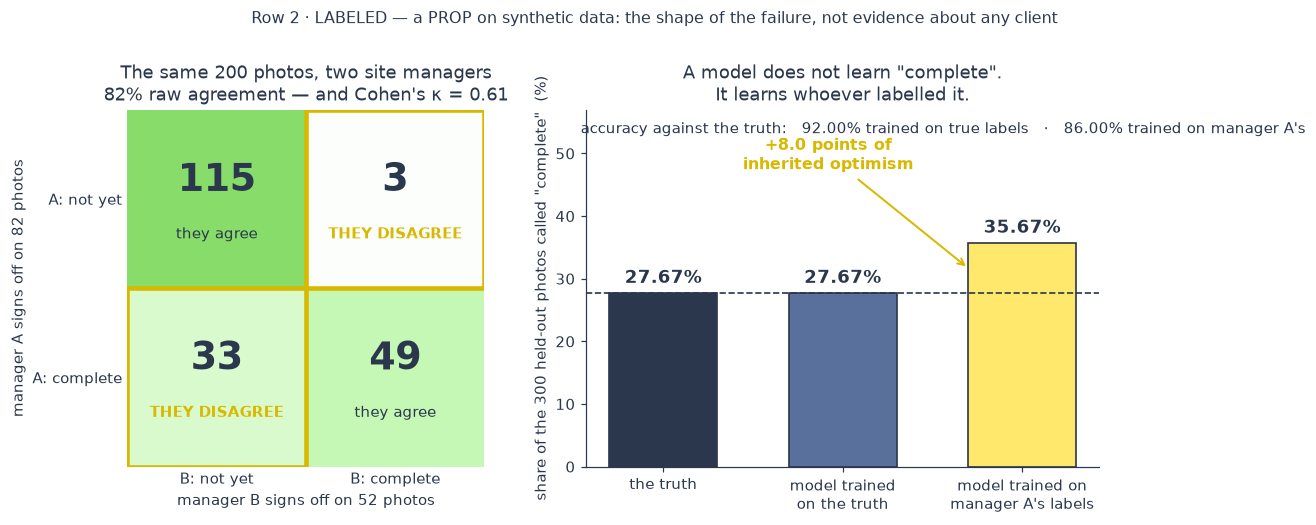

Use the left panel in a room and the right panel in a proposal. The left one is a question
('would your two supervisors land in the yellow squares?'), and every client knows the answer
before they say it. The right one is the consequence, and it is the one that turns a labelling
budget from an expense into an obvious purchase.


In [6]:
# --- FIGURE 1: the two pictures behind row 2. Left - where two honest people disagree.
#     Right - what the model does with one person's judgement.
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.7))

# ---- left: the 2x2 agreement grid on the audit sample
_grid = np.array([[int(((MGR_A[AUDIT] == _a) & (MGR_B[AUDIT] == _b)).sum())
                   for _b in (0, 1)] for _a in (0, 1)])
_cmap = plt.matplotlib.colors.LinearSegmentedColormap.from_list(
    "vsp_agree", ["#ffffff", VSP["mint"], VSP["green"]])
# vmax deliberately above the largest cell so even the busiest square stays legible under
# dark annotation text (SI-19: look at the render, then fix the contrast).
axes[0].imshow(_grid, cmap=_cmap, vmin=0, vmax=_grid.max() * 1.55)
# Loop indices are _ri / _ci, never _i: `_i` is IPython-reserved input history (SI-28a / LL-41).
for _ri in (0, 1):
    for _ci in (0, 1):
        _agree = _ri == _ci
        axes[0].text(_ci, _ri - 0.10, f"{_grid[_ri, _ci]}", ha="center", va="center", fontsize=25,
                     fontweight="bold", color=VSP["ink"])
        axes[0].text(_ci, _ri + 0.20, "they agree" if _agree else "THEY DISAGREE", ha="center",
                     va="center", fontsize=9.5, fontweight="bold" if not _agree else "normal",
                     color=VSP["ink"] if _agree else VSP["gold_dark"])
        if not _agree:
            axes[0].add_patch(plt.Rectangle((_ci - 0.5, _ri - 0.5), 1, 1, fill=False,
                                            edgecolor=VSP["gold_dark"], linewidth=3.0))
axes[0].set_xticks([0, 1], ["B: not yet", "B: complete"], fontsize=10)
axes[0].set_yticks([0, 1], ["A: not yet", "A: complete"], fontsize=10)
axes[0].set_title(f"The same {N_AUDIT} photos, two site managers\n"
                  f"{AGREEMENT:.0%} raw agreement — and Cohen's κ = {KAPPA:.2f}", fontsize=12)
axes[0].set_xlabel(f"manager B signs off on {B_SIGNS_OFF} photos")
axes[0].set_ylabel(f"manager A signs off on {A_SIGNS_OFF} photos")
for _s in ("top", "right", "bottom", "left"):
    axes[0].spines[_s].set_visible(False)
axes[0].tick_params(length=0)

# ---- right: share of the held-out photos called "complete", plus accuracy against the truth
_labels = ["the truth", "model trained\non the truth", "model trained on\nmanager A's labels"]
_vals = [100 * RATE_TRUE, 100 * RATE_GOLD, 100 * RATE_NOISY]
_colours = [VSP["ink"], VSP["navy"], VSP["yellow"]]
_bars = axes[1].bar(_labels, _vals, color=_colours, edgecolor=VSP["ink"], linewidth=1.1, width=0.6)
for _bar, _v in zip(_bars, _vals):
    axes[1].annotate(f"{_v:.2f}%", (_bar.get_x() + _bar.get_width() / 2, _v), fontsize=12,
                     fontweight="bold", ha="center", va="bottom", color=VSP["ink"],
                     textcoords="offset points", xytext=(0, 4))
axes[1].axhline(100 * RATE_TRUE, color=VSP["ink"], linestyle="--", linewidth=1.1)
axes[1].annotate(f"+{100 * (RATE_NOISY - RATE_TRUE):.1f} points of\ninherited optimism",
                 xy=(1.70, 0.5 * (100 * RATE_NOISY + 100 * RATE_TRUE)), xytext=(0.92, 47.5),
                 fontsize=10.5, fontweight="bold", color=VSP["gold_dark"], ha="center",
                 arrowprops=dict(arrowstyle="->", color=VSP["gold_dark"], linewidth=1.3))
# The accuracy line goes in the empty top-left corner, NOT across the bars (SI-19).
axes[1].text(-0.46, 55.0, f"accuracy against the truth:   {ACC_GOLD:.2%} trained on true labels"
                          f"   ·   {ACC_NOISY:.2%} trained on manager A's",
             fontsize=9.5, color=VSP["ink"], ha="left", va="top")
axes[1].set_ylabel("share of the 300 held-out photos called \"complete\"  (%)")
axes[1].set_ylim(0, 57)
axes[1].set_title("A model does not learn \"complete\".\nIt learns whoever labelled it.", fontsize=12)
axes[1].spines[["top", "right"]].set_visible(False)

fig.suptitle("Row 2 · LABELED — a PROP on synthetic data: the shape of the failure, not evidence "
             "about any client", fontsize=10.5, color=VSP["ink"], y=1.005)
plt.tight_layout()
plt.show()

print("Use the left panel in a room and the right panel in a proposal. The left one is a question")
print("('would your two supervisors land in the yellow squares?'), and every client knows the answer")
print("before they say it. The right one is the consequence, and it is the one that turns a labelling")
print("budget from an expense into an obvious purchase.")

In [7]:
# --- ROW 2 - LABELED, part 3: what a label costs. Arithmetic on HYPOTHETICAL inputs - the
#     seconds-per-photo and the hourly rate are placeholders, NOT numbers from any client.
#     [GAP-5] The case brief will supply the real volumes; the shape of the ladder will not change.
HYPOTHETICAL_SECONDS_PER_LABEL = 45      # placeholder: one photo, one milestone, one judgement
HYPOTHETICAL_HOURLY_RATE = 80            # placeholder: a person qualified to make that judgement

rule("ROW 2 - LABELED: the cost ladder  [HYPOTHETICAL INPUTS - see the comment above]")
print(f"Assumptions, both placeholders: {HYPOTHETICAL_SECONDS_PER_LABEL}s per label, "
      f"${HYPOTHETICAL_HOURLY_RATE}/h for somebody who can actually make the call.")
print()
_rows = []
for _n, _acc in ((200, CURVE[2][1]), (1_000, CURVE[3][1]), (10_000, CURVE[4][1])):
    _hours = _n * HYPOTHETICAL_SECONDS_PER_LABEL / 3_600
    _rows.append({
        "labelled examples": f"{_n:,}",
        "labelling hours": f"{_hours:,.1f}",
        "cost at the placeholder rate": f"${_hours * HYPOTHETICAL_HOURLY_RATE:,.0f}",
        "one-off audit (200 double-labelled)": f"${(200 * HYPOTHETICAL_SECONDS_PER_LABEL / 3_600) * HYPOTHETICAL_HOURLY_RATE:,.0f}",
        "what YOUR curve says (MNIST)": f"{_acc:.2%}",
    })
show(pd.DataFrame(_rows).set_index("labelled examples"))
_h200 = 200 * HYPOTHETICAL_SECONDS_PER_LABEL / 3_600
_h1k = 1_000 * HYPOTHETICAL_SECONDS_PER_LABEL / 3_600
_h10k = 10_000 * HYPOTHETICAL_SECONDS_PER_LABEL / 3_600
print()
print("Three things fall out of that table, and all three are pre-sales sentences:")
print()
print(f"1. The audit is nearly free. Double-labelling 200 photos costs about "
      f"{_h200:.1f} hours -")
print(f"   ${_h200 * HYPOTHETICAL_HOURLY_RATE:,.0f} of somebody's time - and it is the only way to learn the ceiling BEFORE")
print("   you commit to a number. Ask for it in the first meeting; it is a small ask that makes")
print("   VSP look like the only vendor who has done this before.")
print()
print(f"2. Ten times the data costs ten times the labelling: {_h1k:.1f} hours becomes "
      f"{_h10k:.0f} hours.")
print(f"   The curve paid {100 * (CURVE[4][1] - CURVE[3][1]):.1f} points for that 10x "
      f"({CURVE[3][1]:.2%} -> {CURVE[4][1]:.2%}).")
print("   LSN-1.4 showed the other half of that trade: every 10x more labelled data bought a")
print("   roughly constant number of accuracy points. Linear cost, sub-linear benefit - which is")
print("   exactly why 'how much data do you need?' is a commercial question, not a technical one.")
print()
print("3. The line item that gets cut is the one nobody named. A labelling budget with a volume, a")
print("   rate and an owner survives procurement. 'We'll figure out labelling later' does not - it")
print("   just becomes an engineer labelling photos at 2am, badly, three weeks before the demo.")

assert (abs(_h200 - 2.5) < 1e-9 and abs(_h1k - 12.5) < 1e-9 and abs(_h10k - 125.0) < 1e-9)
print(f"\n[PASS] Cost ladder pinned on the placeholder assumptions: {_h200:.1f} h / {_h1k:.1f} h / "
      f"{_h10k:.0f} h at 200 / 1,000 / 10,000 labels.")

            ROW 2 - LABELED: the cost ladder  [HYPOTHETICAL INPUTS - see the comment above]             
Assumptions, both placeholders: 45s per label, $80/h for somebody who can actually make the call.



,labelling hours,cost at the placeholder rate,one-off audit (200 double-labelled),what YOUR curve says (MNIST)
labelled examples,,,,
200,2.5,$200,$200,64.41%
"1,000",12.5,"$1,000",$200,84.23%
"10,000",125.0,"$10,000",$200,92.77%



Three things fall out of that table, and all three are pre-sales sentences:

1. The audit is nearly free. Double-labelling 200 photos costs about 2.5 hours -
   $200 of somebody's time - and it is the only way to learn the ceiling BEFORE
   you commit to a number. Ask for it in the first meeting; it is a small ask that makes
   VSP look like the only vendor who has done this before.

2. Ten times the data costs ten times the labelling: 12.5 hours becomes 125 hours.
   The curve paid 8.5 points for that 10x (84.23% -> 92.77%).
   LSN-1.4 showed the other half of that trade: every 10x more labelled data bought a
   roughly constant number of accuracy points. Linear cost, sub-linear benefit - which is
   exactly why 'how much data do you need?' is a commercial question, not a technical one.

3. The line item that gets cut is the one nobody named. A labelling budget with a volume, a
   rate and an owner survives procurement. 'We'll figure out labelling later' does not - it
   just becomes

## Row 3 · **Enough** — *"How many examples — especially of the rare outcome you care about?"*

**This is the row you already have a chart for, and you made it.** `LSN-1.4` trained the same 101,770-parameter
network on 10, 100, 200, 1,000, 10,000 and 60,000 labelled MNIST digits and graded every one on the same
10,000 held-out images. Nothing else changed — same architecture, same seed, same test set, **only the amount
of labelled data.** The next cell re-plots it from those pinned numbers.

**Read the shape, not the points.** It is close to a straight line against a **log** x-axis. That means: **every
10× more labelled data buys a roughly constant number of accuracy points — and costs ten times as much to
label.** That single sentence is the economics of every supervised proposal VSP will ever write, and it is why
"how much data do you need?" is a commercial question wearing a technical hat.

**The failure this row catches, verbatim: *"40 examples of the event of interest won't train anything; base
rates bite."*** Both clauses matter, and the second is the one that ambushes people:

- **The count that matters is the count of the outcome, not the count of rows.** A client with 12,000 photos
  and a milestone that occurs on 40 of them has **40 examples**, not 12,000. Every question in the bank about
  volume should be asked about the *rare* class, because that is the class the client is paying to detect.
- **And when the rare class is rare enough, your metric lies.** `LSN-0.3` priced this exactly: 100 fraud cases
  in 10,098 alerts → **0.98%** precision, one real alert per 102. `LSN-1.3` showed the rubber stamp: a model
  that flags nothing scores **99.20%** accuracy on an imbalanced problem and is worth precisely zero. **Rare
  outcome + accuracy as the metric = a number that cannot fail and cannot help.**

**The honest upside, and say it in the same breath — because "no" is not the goal.** Every point on that curve
is a model trained **from scratch**. Nobody starts from scratch on images any more: you start from a network
already trained on millions of photographs and fine-tune it, which **shifts the whole curve left**, sometimes
by an order of magnitude. That is a real, sellable answer to *"we only have 200 photos."* What does **not**
change is the shape: **less labelled data, less model. Always.**

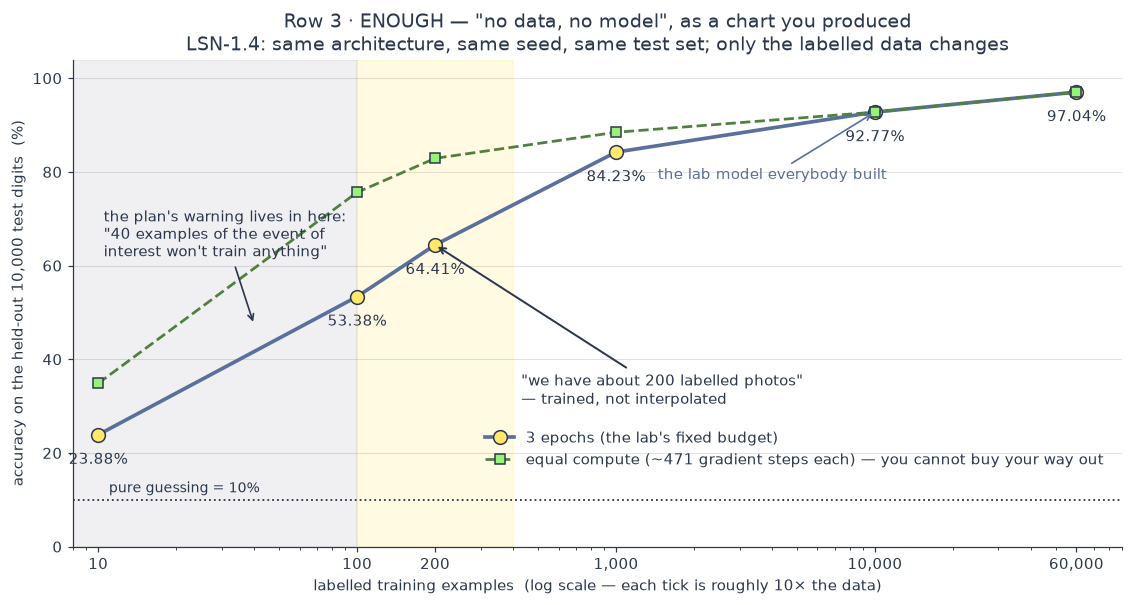

THE THREE SENTENCES THIS CHART GIVES YOU IN A MEETING:

1. "On the easiest image problem that exists - ten classes, centred, no lighting, no
    occlusion, every label correct - 200 labelled examples bought 64%. Your site
    photos are harder in every direction that matters."
2. "Ten times the data was worth about 8.5 points here, and ten times the
    labelling cost. That trade is the project plan."
3. "And this is the honest good news: every point on that line was trained from scratch.
    Starting from a network already trained on millions of photographs moves the whole line
    left. That is the conversation worth having about your 200 photos."

[PASS] All six curve points pinned to LSN-1.4: 23.88 / 53.38 / 64.41 / 84.23 / 92.77 / 97.04 %.


In [8]:
# --- FIGURE 2: THE DEGRADATION CURVE. Not re-trained - QUOTED from LSN-1.4's executed outputs
#     and pinned by the asserts at the bottom. This is the chart the lesson opens on, and the
#     reason it carries weight in a client meeting is that the room built it.
fig, ax = plt.subplots(figsize=(10.4, 5.6))
_fixed = [100 * a for _n, a, _b in CURVE]
_fair = [100 * b for _n, _a, b in CURVE]

ax.plot(CURVE_N, _fixed, "o-", color=VSP["navy"], linewidth=2.4, markersize=9,
        markerfacecolor=VSP["yellow"], markeredgecolor=VSP["ink"],
        label="3 epochs (the lab's fixed budget)")
ax.plot(CURVE_N, _fair, "s--", color=VSP["green_dark"], linewidth=1.8, markersize=7,
        markerfacecolor=VSP["mint"], markeredgecolor=VSP["ink"],
        label="equal compute (~471 gradient steps each) — you cannot buy your way out")
ax.axhline(100 * GUESSING, color=VSP["ink"], linestyle=":", linewidth=1.2)
ax.text(11, 100 * GUESSING + 1.6, "pure guessing = 10%", fontsize=9, color=VSP["ink"])

for _n, _a, _b in CURVE:
    ax.annotate(f"{_a:.2%}", (_n, 100 * _a), textcoords="offset points", xytext=(0, -19),
                ha="center", fontsize=9.5, color=VSP["ink"])

# The client point LSN-1.4 trained rather than interpolated.
ax.axvspan(100, 400, color=VSP["yellow"], alpha=0.20, zorder=0)
ax.annotate("\"we have about 200 labelled photos\"\n— trained, not interpolated",
            xy=(200, 100 * CLIENT_200), xytext=(430, 30.5), fontsize=10, color=VSP["ink"],
            ha="left", arrowprops=dict(arrowstyle="->", color=VSP["ink"], linewidth=1.3))
# The plan's "40 examples of the event of interest" - off the left edge of anything usable.
ax.axvspan(8, 100, color=VSP["ink"], alpha=0.07, zorder=0)
ax.annotate(f"the plan's warning lives in here:\n\"{RARE_EVENT_N} examples of the event of\n"
            f"interest won't train anything\"",
            xy=(RARE_EVENT_N, 100 * CURVE[1][1] - 6), xytext=(10.5, 62), fontsize=9.5,
            color=VSP["ink"], ha="left",
            arrowprops=dict(arrowstyle="->", color=VSP["ink"], linewidth=1.1))
ax.annotate("the lab model everybody built", xy=(10_000, 100 * LAB_ACC), xytext=(1_450, 78.5),
            fontsize=9.5, color=VSP["navy"],
            arrowprops=dict(arrowstyle="->", color=VSP["navy"], linewidth=1.1))

ax.set_xscale("log")
ax.set_xticks(CURVE_N)
ax.set_xticklabels([f"{n:,}" for n in CURVE_N])
ax.set_xlim(8, 90_000)
ax.set_ylim(0, 104)
ax.set_xlabel("labelled training examples  (log scale — each tick is roughly 10× the data)")
ax.set_ylabel("accuracy on the held-out 10,000 test digits  (%)")
ax.set_title("Row 3 · ENOUGH — \"no data, no model\", as a chart you produced\n"
             "LSN-1.4: same architecture, same seed, same test set; only the labelled data changes",
             fontsize=12.5)
# Legend sits ABOVE the 10%-guessing dotted line: a frameless legend printed across a dotted
# reference line is unreadable (LL-10, learned in LSN-0.2).
ax.legend(loc="lower right", fontsize=9.5, bbox_to_anchor=(0.995, 0.135))
ax.grid(axis="y", color=VSP["ink"], alpha=0.14, linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("THE THREE SENTENCES THIS CHART GIVES YOU IN A MEETING:")
print()
print(f"1. \"On the easiest image problem that exists - ten classes, centred, no lighting, no")
print(f"    occlusion, every label correct - 200 labelled examples bought {CLIENT_200:.0%}. Your site")
print(f"    photos are harder in every direction that matters.\"")
print(f"2. \"Ten times the data was worth about {100 * (CURVE[4][1] - CURVE[3][1]):.1f} points here, and ten times the")
print(f"    labelling cost. That trade is the project plan.\"")
print(f"3. \"And this is the honest good news: every point on that line was trained from scratch.")
print(f"    Starting from a network already trained on millions of photographs moves the whole line")
print(f"    left. That is the conversation worth having about your 200 photos.\"")

# --- pinned against LSN-1.4's executed output (SI-17). If the curve ever drifts, this fails.
assert all(abs(_got - _want) < 1e-9 for _got, _want in
           zip(_fixed, [23.88, 53.38, 64.41, 84.23, 92.77, 97.04])), _fixed
assert all(abs(_got - _want) < 1e-9 for _got, _want in
           zip(_fair, [34.86, 75.63, 82.90, 88.46, 92.77, 97.04])), _fair
print(f"\n[PASS] All six curve points pinned to LSN-1.4: 23.88 / 53.38 / 64.41 / 84.23 / 92.77 / "
      f"97.04 %.")

In [9]:
# --- ROW 3 - ENOUGH: the arithmetic that turns "we have 12,000 photos" into "you have 40
#     examples". No model here, no simulation - just the division nobody does in the meeting.
#     [GAP-5] The volumes below are HYPOTHETICAL placeholders for the shape of the calculation;
#     the case brief supplies the real ones.
HYPOTHETICAL_ARCHIVE = 12_000        # placeholder: "we have thousands of site photos"
MILESTONE_TYPES = 14                 # placeholder: milestones tracked per building

rule("ROW 3 - ENOUGH: dividing the archive by the question  [HYPOTHETICAL PLACEHOLDERS]")
print(f"A client says: \"we have about {HYPOTHETICAL_ARCHIVE:,} site photos.\" True, and almost irrelevant.")
print(f"They want per-milestone completion detection across {MILESTONE_TYPES} milestone types.")
print()
_per_type = HYPOTHETICAL_ARCHIVE / MILESTONE_TYPES
print(f"  {'photos in the archive':<48}{HYPOTHETICAL_ARCHIVE:>8,}")
print(f"  {'milestone types they want detected':<48}{MILESTONE_TYPES:>8,}")
print(f"  {'... so photos per milestone type, if evenly spread':<48}{_per_type:>8,.0f}")
print()
print(f"  and milestones are NOT evenly spread. A slab pour happens on every floor; a")
print(f"  {RARE_EVENT_N}-photo milestone happens once per building.")
print()
_bands = [("a common milestone", 1_000, CURVE[3][1]),
          ("a middling milestone", 200, CURVE[2][1]),
          ("a rare milestone (the plan's number)", RARE_EVENT_N, None),
          ("the rarest one they will ask about first", 10, CURVE[0][1])]
_rows = []
for _name, _n, _acc in _bands:
    _rows.append({
        "the class you are detecting": _name,
        "labelled examples of it": f"{_n:,}",
        "nearest point on YOUR curve": (f"{_acc:.2%}" if _acc is not None
                                        else f"between {CURVE[0][1]:.2%} and {CURVE[1][1]:.2%}"),
        "what you can honestly promise": ("a pilot" if _n >= 200 else "data collection, not a model"),
    })
show(pd.DataFrame(_rows).set_index("the class you are detecting"))
print()
print("AND THE SECOND HALF OF THE ROW - the one that ambushes people. When the class is rare, the")
print("metric stops working. Two numbers from earlier in the programme, both of them yours:")
print()
print("  LSN-0.3, the fraud construction : 100 real cases inside 10,098 alerts -> 0.98% precision,")
print("                                    one real alert per 102. A 99.0%-accurate detector.")
print("  LSN-1.3, the rubber stamp       : a model that flags NOTHING scored 99.20% accuracy on")
print("                                    the same imbalanced problem, and is worth zero.")
print()
print("So the question in the bank is deliberately worded 'the outcome you actually care about -")
print("especially if it's rare', and the follow-up is always: 'and how would we know it is working?'")
print("That hands the conversation to LSN-1.3's question - false alarm versus miss - which is")
print("question 9 in the bank for exactly this reason.")

assert abs(_per_type - 857.142857) < 1e-3, _per_type
assert RARE_EVENT_N == 40 and CURVE[1][1] == 0.5338 and CURVE[0][1] == 0.2388
print(f"\n[PASS] Row 3 pinned: {HYPOTHETICAL_ARCHIVE:,} / {MILESTONE_TYPES} = "
      f"{_per_type:,.0f} photos per milestone type before the rare classes are counted.")

           ROW 3 - ENOUGH: dividing the archive by the question  [HYPOTHETICAL PLACEHOLDERS]            
A client says: "we have about 12,000 site photos." True, and almost irrelevant.
They want per-milestone completion detection across 14 milestone types.

  photos in the archive                             12,000
  milestone types they want detected                    14
  ... so photos per milestone type, if evenly spread     857

  and milestones are NOT evenly spread. A slab pour happens on every floor; a
  40-photo milestone happens once per building.



,labelled examples of it,nearest point on YOUR curve,what you can honestly promise
the class you are detecting,,,
a common milestone,"1,000",84.23%,a pilot
a middling milestone,200,64.41%,a pilot
a rare milestone (the plan's number),40,between 23.88% and 53.38%,"data collection, not a model"
the rarest one they will ask about first,10,23.88%,"data collection, not a model"



AND THE SECOND HALF OF THE ROW - the one that ambushes people. When the class is rare, the
metric stops working. Two numbers from earlier in the programme, both of them yours:

  LSN-0.3, the fraud construction : 100 real cases inside 10,098 alerts -> 0.98% precision,
                                    one real alert per 102. A 99.0%-accurate detector.
  LSN-1.3, the rubber stamp       : a model that flags NOTHING scored 99.20% accuracy on
                                    the same imbalanced problem, and is worth zero.

So the question in the bank is deliberately worded 'the outcome you actually care about -
especially if it's rare', and the follow-up is always: 'and how would we know it is working?'
That hands the conversation to LSN-1.3's question - false alarm versus miss - which is
question 9 in the bank for exactly this reason.

[PASS] Row 3 pinned: 12,000 / 14 = 857 photos per milestone type before the rare classes are counted.


## Row 4 · **Fresh** — *"How recent is the data, and has the business changed since it was collected?"*

**The failure this catches, verbatim: *"A model trained on the pre-reorg world confidently predicts a world that
no longer exists."*** Every word in that sentence is load-bearing, and **"confidently"** is the one that costs
money. A stale model does not throw an error. It does not return `null`. It returns the same crisp,
well-formatted, high-probability answers it always did, about a world that moved.

**The two shapes of staleness, and only one of them is visible.**

- **The inputs changed.** New cameras, new lighting, drone instead of mast, winter instead of summer. This one
  is at least *detectable* — you can watch the distribution of what arrives and notice it move.
- **The meaning changed.** The client switched to prefabricated panels, so the visual cue that used to mean
  "framing complete" now means something else entirely. The photos still look like photos. **Nothing about the
  input tells you the label rule changed.** The only thing that finds this is *freshly labelled data* — which
  is why "how do we know it is still right?" and "who keeps labelling?" are the same question.

**The prop, and the same prop as row 2.** One coherent world across the whole lesson (`LL-30`'s house pattern):
the model we already trained on "season 1" photos is now shown 600 photos from sites built a different way. We
change nothing about the model. We just ask it, and then we check both its **accuracy** and its
**confidence** — because in a client conversation, those two numbers moving in opposite directions is the whole
argument for a monitoring line item.

In [10]:
# --- ROW 4 - FRESH: the world moved, the model did not. Same GOLD_MODEL from row 2, no
#     re-training, no re-tuning. 600 photos from sites using a new construction method, so three
#     of the six visual cues now mean something different.  [PROP: synthetic]
N_SEASON_2 = 600
# The same six cues - but cue 1 has weakened, cue 2 has FLIPPED SIGN, cue 3 has flipped and faded.
# In the story: prefabricated panels replaced poured-in-place, so "wet surface visible" stopped
# meaning "just finished" and started meaning "not started".
CUE_SEASON_2 = np.array([0.6, +1.1, -0.3, 0.7, -0.6, 0.5])

RNG_2 = np.random.default_rng(SEED + 1)
TRUTH_2 = (RNG_2.random(N_SEASON_2) < BASE_RATE).astype(int)
X_SEASON_2 = RNG_2.normal(size=(N_SEASON_2, 6)) + np.outer(TRUTH_2, CUE_SEASON_2) * CUE_STRENGTH

PRED_S1, CONF_S1 = GOLD_MODEL.predict(X_PHOTOS[TEST]), GOLD_MODEL.predict_proba(X_PHOTOS[TEST]).max(axis=1)
PRED_S2, CONF_S2 = GOLD_MODEL.predict(X_SEASON_2), GOLD_MODEL.predict_proba(X_SEASON_2).max(axis=1)
ACC_S1, ACC_S2 = float(accuracy_score(TRUTH[TEST], PRED_S1)), float(accuracy_score(TRUTH_2, PRED_S2))
MEAN_CONF_S1, MEAN_CONF_S2 = float(CONF_S1.mean()), float(CONF_S2.mean())
RATE_S2, TRUE_RATE_S2 = float(PRED_S2.mean()), float(TRUTH_2.mean())
SURE_MASK = CONF_S2 >= 0.90
SHARE_SURE = float(SURE_MASK.mean())
ACC_WHEN_SURE = float(accuracy_score(TRUTH_2[SURE_MASK], PRED_S2[SURE_MASK]))

rule("ROW 4 - FRESH: the same model, a world that moved  [PROP]")
print(f"{'':<34}{'season 1 (held out)':>22}{'season 2 (new method)':>24}")
print("-" * 82)
print(f"{'photos scored':<34}{TRUTH[TEST].size:>22,}{N_SEASON_2:>24,}")
print(f"{'accuracy':<34}{ACC_S1:>21.2%}{ACC_S2:>24.2%}")
print(f"{'mean confidence in its own answer':<34}{MEAN_CONF_S1:>21.2%}{MEAN_CONF_S2:>24.2%}")
print(f"{'it says complete':<34}{RATE_GOLD:>21.2%}{RATE_S2:>24.2%}")
print(f"{'actually complete':<34}{RATE_TRUE:>21.2%}{TRUE_RATE_S2:>24.2%}")
print("-" * 82)
print()
print(f"ACCURACY FELL {100 * (ACC_S1 - ACC_S2):.2f} POINTS. CONFIDENCE WENT "
      f"{'UP' if MEAN_CONF_S2 > MEAN_CONF_S1 else 'DOWN'} "
      f"{abs(100 * (MEAN_CONF_S2 - MEAN_CONF_S1)):.2f}.")
print()
print(f"  - {SHARE_SURE:.1%} of its answers on the new sites came with at least 90% confidence.")
print(f"    Those answers were right {ACC_WHEN_SURE:.2%} of the time.")
print(f"  - It reports {RATE_S2:.2%} of the new sites complete. {TRUE_RATE_S2:.2%} are. On a progress")
print(f"    dashboard that reads as a project running catastrophically late - and somebody would")
print(f"    have chased a schedule instead of chasing the model.")
print()
print("THE POINT, and it is the one to say out loud in a client meeting:")
print("  A model has no way to tell you that the world changed. It was fitted on one world and it")
print("  answers every question as if that world still exists, with exactly the same certainty it")
print("  had when it was right. Nothing about the output is different. The only thing that catches")
print("  this is fresh labelled data - which means the answer to 'how do we know it's still")
print("  working?' is always a person, a cadence, and a line item.")
print()
print("Two more callbacks worth naming, because the room has already seen both:")
print("  LSN-0.4's overconfident twin  - identical decisions, a 9.6-point confidence lie. Confidence")
print("                                  is a number the model computes, not a measure of truth.")
print("  LSN-1.4's stale-weights trap  - reusing already-trained weights reported 91.16% when the")
print("                                  honest answer was 53.38%. Same failure family: a number")
print("                                  that looks fine because nothing checked it.")

assert abs(ACC_S1 - 0.9200) < 5e-4 and abs(ACC_S2 - 0.6650) < 5e-4, (ACC_S1, ACC_S2)
assert abs(MEAN_CONF_S1 - 0.9012) < 5e-4 and abs(MEAN_CONF_S2 - 0.9072) < 5e-4
assert MEAN_CONF_S2 > MEAN_CONF_S1, "the whole beat is that confidence does NOT fall"
assert abs(RATE_S2 - 0.0783) < 5e-4 and abs(TRUE_RATE_S2 - 0.3167) < 5e-4
assert abs(SHARE_SURE - 0.7050) < 5e-4 and abs(ACC_WHEN_SURE - 0.7210) < 5e-4
print(f"\n[PASS] Pinned: {ACC_S1:.2%} -> {ACC_S2:.2%} accuracy while confidence went "
      f"{MEAN_CONF_S1:.2%} -> {MEAN_CONF_S2:.2%}.")

                       ROW 4 - FRESH: the same model, a world that moved  [PROP]                        
                                     season 1 (held out)   season 2 (new method)
----------------------------------------------------------------------------------
photos scored                                        300                     600
accuracy                                         92.00%                  66.50%
mean confidence in its own answer                90.12%                  90.72%
it says complete                                 27.67%                   7.83%
actually complete                                27.67%                  31.67%
----------------------------------------------------------------------------------

ACCURACY FELL 25.50 POINTS. CONFIDENCE WENT UP 0.60.

  - 70.5% of its answers on the new sites came with at least 90% confidence.
    Those answers were right 72.10% of the time.
  - It reports 7.83% of the new sites complete. 31.67% are. On a p

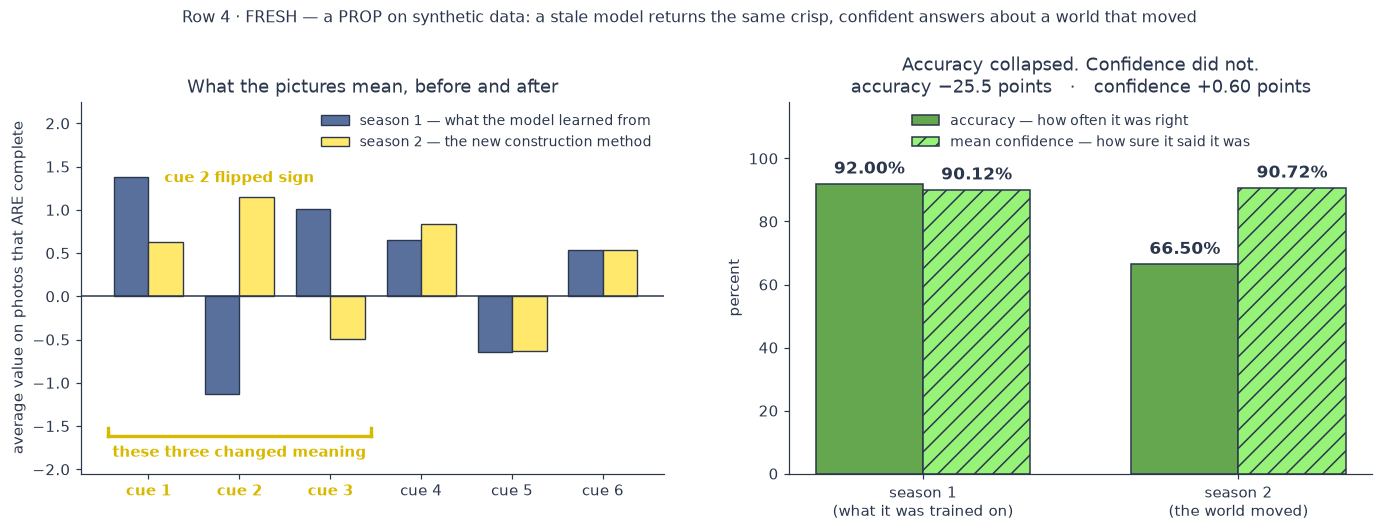

The right panel is the slide. Two bars per group, same axis, same units: how often it was
right, and how sure it said it was. They agree on the left and they disagree on the right,
and that disagreement is the entire case for a refresh cadence in the SOW.


In [11]:
# --- FIGURE 3: what "stale" looks like. Left - the cues whose meaning changed. Right - the two
#     numbers moving in opposite directions, which is the whole argument for monitoring.
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.9))

# ---- left: the average cue value on photos that ARE complete, season 1 vs season 2
_cues = np.arange(6)
_s1 = X_PHOTOS[TRAIN][TRUTH[TRAIN] == 1].mean(axis=0)
_s2 = X_SEASON_2[TRUTH_2 == 1].mean(axis=0)
_w = 0.38
axes[0].bar(_cues - _w / 2, _s1, _w, color=VSP["navy"], edgecolor=VSP["ink"], linewidth=0.9,
            label="season 1 — what the model learned from")
axes[0].bar(_cues + _w / 2, _s2, _w, color=VSP["yellow"], edgecolor=VSP["ink"], linewidth=0.9,
            label="season 2 — the new construction method")
axes[0].axhline(0, color=VSP["ink"], linewidth=1.0)
# The three changed cues get a BRACKET under the bars, not a box around them: cue 2's season-1
# bar reaches -1.13, so any box big enough to hold it collides with the legend (SI-19).
_bracket_y = -1.62
axes[0].plot([-0.45, 2.45], [_bracket_y, _bracket_y], color=VSP["gold_dark"], linewidth=2.2)
for _x in (-0.45, 2.45):
    axes[0].plot([_x, _x], [_bracket_y, _bracket_y + 0.10], color=VSP["gold_dark"], linewidth=2.2)
axes[0].text(1.0, _bracket_y - 0.10, "these three changed meaning", ha="center", va="top",
             fontsize=10, fontweight="bold", color=VSP["gold_dark"])
axes[0].text(1.0, 1.28, "cue 2 flipped sign", ha="center", va="bottom", fontsize=9.5,
             fontweight="bold", color=VSP["gold_dark"])
axes[0].set_xticks(_cues, [f"cue {i + 1}" for i in _cues], fontsize=9.5)
for _ix, _tick in enumerate(axes[0].get_xticklabels()):
    if _ix < 3:
        _tick.set_color(VSP["gold_dark"])
        _tick.set_fontweight("bold")
axes[0].set_ylabel("average value on photos that ARE complete")
axes[0].set_ylim(-2.05, 2.25)
axes[0].set_title("What the pictures mean, before and after", fontsize=12)
axes[0].legend(fontsize=9, loc="upper right", bbox_to_anchor=(1.0, 1.0))
axes[0].spines[["top", "right"]].set_visible(False)

# ---- right: accuracy vs confidence, same units, no twinx (SI-28b)
_groups = np.arange(2)
_acc_pair = [100 * ACC_S1, 100 * ACC_S2]
_conf_pair = [100 * MEAN_CONF_S1, 100 * MEAN_CONF_S2]
_bw = 0.34
_b1 = axes[1].bar(_groups - _bw / 2, _acc_pair, _bw, color=VSP["green"], edgecolor=VSP["ink"],
                  linewidth=1.0, label="accuracy — how often it was right")
_b2 = axes[1].bar(_groups + _bw / 2, _conf_pair, _bw, color=VSP["mint"], edgecolor=VSP["ink"],
                  linewidth=1.0, hatch="//", label="mean confidence — how sure it said it was")
for _bars, _vals in ((_b1, _acc_pair), (_b2, _conf_pair)):
    for _bar, _v in zip(_bars, _vals):
        axes[1].annotate(f"{_v:.2f}%", (_bar.get_x() + _bar.get_width() / 2, _v), fontsize=11,
                         fontweight="bold", ha="center", va="bottom", color=VSP["ink"],
                         textcoords="offset points", xytext=(0, 4))
# Headroom above the bars, and the two deltas live in the TITLE rather than on the plot: an
# arrow between the accuracy bars collided with the "66.50%" label, and a text block collided
# with the legend (SI-19 - two renders to get here).
axes[1].set_ylim(0, 118)
axes[1].set_xticks(_groups, ["season 1\n(what it was trained on)", "season 2\n(the world moved)"],
                   fontsize=10)
axes[1].set_ylabel("percent")
axes[1].set_title(f"Accuracy collapsed. Confidence did not.\n"
                  f"accuracy −{_acc_pair[0] - _acc_pair[1]:.1f} points   ·   "
                  f"confidence +{_conf_pair[1] - _conf_pair[0]:.2f} points", fontsize=12)
axes[1].legend(fontsize=9, loc="upper center", bbox_to_anchor=(0.5, 1.0))
axes[1].spines[["top", "right"]].set_visible(False)

fig.suptitle("Row 4 · FRESH — a PROP on synthetic data: a stale model returns the same crisp, "
             "confident answers about a world that moved", fontsize=10.5, color=VSP["ink"], y=0.995)
# Explicit margins, not tight_layout: two-line titles plus a suptitle make the automatic engine
# fight itself, and explicit margins are the SI-28b habit anyway.
plt.subplots_adjust(left=0.068, right=0.985, top=0.825, bottom=0.135, wspace=0.215)
plt.show()

print("The right panel is the slide. Two bars per group, same axis, same units: how often it was")
print("right, and how sure it said it was. They agree on the left and they disagree on the right,")
print("and that disagreement is the entire case for a refresh cadence in the SOW.")

## Row 5 · **Legal** — *"Do you own this data and may you use it this way — privacy, contract, people in frame?"*

**The failure this catches, verbatim: *"The model works; the deal dies in legal review."*** This is the only row
on the checklist with no demo, and that is not an oversight — **there is nothing to simulate.** A model cannot
tell you whether you are allowed to train it. What makes this row worth its four minutes is that it is the
cheapest one to ask and the most expensive one to skip: the question costs a sentence in week one, and the
answer costs a re-scope in week twelve.

**Five sub-questions, and notice that only one of them is about privacy.**

| Sub-question | The one it catches | Who actually answers it |
|---|---|---|
| **Do you own it?** | Data the client holds but does not own — a subcontractor's drone footage, a platform's export, a partner's feed | the client's contracts, not the client's engineer |
| **May you use it *this way*?** | Data lawfully collected for one purpose and now proposed for another. Consent for "site records" ≠ consent for "training a model" | whoever wrote the privacy notice |
| **Who is in frame?** | People. Workers are identifiable in site photos, and "identifiable" is the legal threshold, not "named" | the client's counsel, and possibly a works council or union agreement |
| **Where may it live?** | Residency, sub-processors, and whether a single row is allowed to leave the client's tenancy — which decides your entire architecture | security / IT, early, before you design anything |
| **What happens to the model?** | Whether the *trained model* is a deliverable, a shared asset, or something the client owns outright. Models memorise; a model trained on their data can be a data-protection object in itself | the commercial owner of the deal |

**Why the "people in frame" clause is the one that surprises engineers.** A construction-site photo is a
workplace photo of identifiable workers. In much of Europe — and the sponsor's delivery centres are in Romania
— using workplace imagery to train a system that assesses progress can touch employee-monitoring rules that
have nothing to do with whether the client owns the JPEG. **That is not a reason to say no.** It is a reason to
ask in the first meeting, so the answer is "we'll blur faces and get the works-council sign-off" instead of
"we already trained on it."

**The sentence that makes this row an asset rather than a wet blanket:** ***"I'd rather find the legal
constraint in week one than in week twelve — so who owns this data, and has anyone asked whether we can use it
this way?"*** No client has ever been annoyed by that question. Several have been annoyed by its absence.

In [12]:
# --- SEGMENT 1 SCOREBOARD: the five rows, each with the number this hour attached to it. This is
#     the cell to screenshot; it is also the answer key for "what did segment 1 actually give me?"
SCOREBOARD = pd.DataFrame([
    ("Exists",
     "Is it recorded anywhere today?",
     "4 things \"we have the data\" can mean; 1 is a dataset",
     "\"Show me how you answer this today, without a model.\""),
    ("Labeled",
     "Does each example carry the answer? Who adds it, at what cost?",
     f"{AGREEMENT:.0%} agreement, kappa {KAPPA:.2f}; {A_SIGNS_OFF / B_SIGNS_OFF:.2f}x sign-off gap; "
     f"model inherits +{100 * (RATE_NOISY - RATE_TRUE):.1f} pts",
     "\"Could two of your people label the same 50 examples independently?\""),
    ("Enough",
     "How many examples of the RARE outcome?",
     f"your own curve: {CURVE[0][1]:.0%} at 10 -> {CLIENT_200:.0%} at 200 -> {LAB_ACC:.0%} at 10k -> "
     f"{FULL_ACC:.0%} at 60k",
     "\"How many of the outcome you actually care about — not how many rows?\""),
    ("Fresh",
     "How recent, and what changed since?",
     f"accuracy {ACC_S1:.0%} -> {ACC_S2:.0%} while confidence went "
     f"{MEAN_CONF_S1:.1%} -> {MEAN_CONF_S2:.1%}",
     "\"What changed in the business since this data was collected?\""),
    ("Legal",
     "Do you own it, and may you use it this way?",
     "5 sub-questions; only 1 is about privacy",
     "\"Who owns this, and has anyone asked whether we can use it this way?\""),
], columns=["Check", "The question", "The number this hour gave you", "What you ask in the room"])

rule("SEGMENT 1 SCOREBOARD - five rows, five numbers, five questions")
show(SCOREBOARD.set_index("Check"))
print()
print("Every one of those numbers came from this notebook or from a lab you ran. That is the whole")
print("difference between reciting a checklist and running one: a checklist recited sounds like")
print("process, and a checklist with numbers in it sounds like somebody who has done this before.")
print()
print("AND THE THROUGH-LINE, one more time, because it is the sentence the room should leave with:")
print()
print("   Every 'no' on this list is a scoping conversation you want to have BEFORE the SOW,")
print("   not after. You cannot lose a deal by asking. You can only lose it by not asking")
print("   and then discovering.")

assert len(SCOREBOARD) == 5
assert list(SCOREBOARD["Check"]) == ["Exists", "Labeled", "Enough", "Fresh", "Legal"]
print(f"\n[PASS] Segment 1 complete - all five checklist rows carry a number and a question.")

                     SEGMENT 1 SCOREBOARD - five rows, five numbers, five questions                     


,The question,The number this hour gave you,What you ask in the room
Check,,,
Exists,Is it recorded anywhere today?,"4 things ""we have the data"" can mean; 1 is a dataset","""Show me how you answer this today, without a model."""
Labeled,"Does each example carry the answer? Who adds it, at what cost?","82% agreement, kappa 0.61; 1.58x sign-off gap; model inherits +8.0 pts","""Could two of your people label the same 50 examples independently?"""
Enough,How many examples of the RARE outcome?,your own curve: 24% at 10 -> 64% at 200 -> 93% at 10k -> 97% at 60k,"""How many of the outcome you actually care about — not how many rows?"""
Fresh,"How recent, and what changed since?",accuracy 92% -> 66% while confidence went 90.1% -> 90.7%,"""What changed in the business since this data was collected?"""
Legal,"Do you own it, and may you use it this way?",5 sub-questions; only 1 is about privacy,"""Who owns this, and has anyone asked whether we can use it this way?"""



Every one of those numbers came from this notebook or from a lab you ran. That is the whole
difference between reciting a checklist and running one: a checklist recited sounds like
process, and a checklist with numbers in it sounds like somebody who has done this before.

AND THE THROUGH-LINE, one more time, because it is the sentence the room should leave with:

   Every 'no' on this list is a scoping conversation you want to have BEFORE the SOW,
   not after. You cannot lose a deal by asking. You can only lose it by not asking
   and then discovering.

[PASS] Segment 1 complete - all five checklist rows carry a number and a question.


---

# Segment 2 — Case walkthrough: construction-site completion detection *(25 min)*

**How this runs.** Discussion, structured, instructor facilitates — **participants supply the answers.** The
five steps below are the lesson plan's walkthrough structure, verbatim, with their minute budgets. The room
works the prospect end to end; nobody presents.

| Step | Time | What happens |
|---|---|---|
| 1 · **Restate the ask** | 2 min | one person says what the client actually wants, in the client's words |
| 2 · **Triage the job** | 3 min | `LSN-1.1` callback — which of the five ML jobs is this? |
| 3 · **Run the checklist** | 12 min | all five rows against the case. **Your pre-work risks get read out here** |
| 4 · **Where it breaks** | 5 min | four named failure modes, each priced with a number from segment 1 |
| 5 · **What VSP should promise** | 3 min | the scoped answer — and why honest scoping is the sales move |

**Timing check:** 2 + 3 + 12 + 5 + 3 = **25 min**, which is the plan's segment budget. The 12-minute step 3 is
half the segment on purpose: that is the part that is actually hard, and it is the part `ASM-1` grades.

> ## `[GAP-5 — pending Vlad/Dorel case brief]`
>
> **This is the section the brief lands in.** The walkthrough *structure* below is complete and it runs today —
> the lesson plan says so explicitly: *"Case walkthrough structure (runs even before the GAP-5 brief lands)."*
> What is missing is the **prospect's actual facts**: how many sites, how big the photo archive is, who took
> the pictures and why, what the client said in their own words, who signs off on "complete" today.
>
> **The rule this notebook follows:** where a concrete number is needed to teach with, it is either **a number
> you produced in `LSN-1.4`** or **explicitly labelled a hypothetical placeholder**. There are no invented
> client facts anywhere in this section. When the brief arrives, its numbers replace the placeholders in step
> 3 and step 5, and the client's own words replace the paraphrase in step 1. **The structure does not change.**

## Step 1 · **Restate the ask** *(2 min)*

> **The plan's wording, verbatim:** *client wants to know, from periodic site photos/video, whether work
> milestones are actually complete.*

**Why this is a step and not a formality.** Restating the ask is the cheapest place to discover that the room
is solving two different problems. Three things a "restate" has to pin down, and the client's own words are the
only acceptable source for all three:

1. **The output.** *"Whether milestones are complete"* — a yes/no per milestone? A percentage? A date estimate?
   Each is a different ML job (step 2), and clients mix them freely in one sentence.
2. **The cadence.** *"Periodic"* — weekly walk-round photos, a fixed mast camera every hour, ad-hoc phone
   pictures when somebody remembers? This decides whether there is a feed or a folder, which is **question 7**
   in the bank.
3. **The decision.** *Who acts differently* once they know? Progress billing, schedule escalation, a client
   report, a retention release? This is **question 1** in the bank and it is the one that decides whether the
   project is worth doing at all.

> ### `[GAP-5 — pending Vlad/Dorel case brief]`
>
> **The client's own words go here.** A paraphrase is not the same artifact: "are the milestones complete" and
> "I want to stop sending a guy out to check" are the same ask with completely different economics, and only
> one of them tells you what the model has to beat (**question 10**). Until the brief lands, run step 1 on the
> paraphrase above and flag, out loud, that the room is working from a paraphrase.

**The facilitator's move, and it is worth the two minutes:** ask one person to restate the ask, then ask a
second person whether they heard the same thing. If the two restatements differ, **that difference is the
project's first risk** — and it has nothing to do with data yet.

## Step 2 · **Triage the job** *(3 min — `LSN-1.1` callback)*

> **The plan's wording, verbatim:** *per-milestone "complete: yes/no" → classification; "% complete" →
> regression; on images → CNN territory (LSN-1.5).*

**This is the fastest three minutes in the lesson, because the room already did it.** `LSN-1.1`'s five jobs, and
this case lands on one of them — but *which* one depends entirely on the answer to step 1:

| If the client wants… | The job (`LSN-1.1`) | The output (`LSN-1.2`) | How you'd grade it (`LSN-1.3`) |
|---|---|---|---|
| "is milestone X complete?" | **sort it** — classification | one label per milestone per photo, plus a confidence | confusion matrix; false alarm vs miss (**question 9**) |
| "what % complete is this floor?" | **predict a number** — regression | a number, 0–100 | error per segment — and `LSN-1.3` showed a 38-hour headline MAE hiding 330-hour epic misses |
| "which of these photos are unusual?" | **spot the weird one** — anomaly detection | a score per photo | precision at the top of the list, because nobody reviews the tail |
| "group the sites that behave alike" | **group it** — clustering | cluster assignments | no ground truth; judged by usefulness, not accuracy |
| "write the weekly progress narrative" | **make something new** — generative | text | not this lesson. `MOD-2` |

**`LSN-1.1` taught a genuine tie, and this case *is* the tie.** "% complete" on a construction milestone can be
**classified** (bucket it: not started / in progress / complete) **or regressed** (a number). Both are
defensible. The deciding question is not technical: ***"what does the person receiving this number do
differently at 60% versus 70%?"*** If the answer is "nothing", you have three buckets, not a percentage — and
three buckets need far less data, which is a **row 3** win you just bought by asking a business question.

**And the architecture note, one sentence, from `LSN-1.5`:** it is images, so it is **CNN territory** — a small
pattern detector slid across the frame, stacked into edges → shapes → objects. That is a *how*, not a *whether*,
and the whole point of this hour is that the *whether* is decided by the next twelve minutes, not by the
architecture.

## Step 3 · **Run the checklist** *(12 min — the heart of the session)*

> **The plan's wording, verbatim:** *Exists — are there historical photos, and from how many sites? Labeled —
> who says which photos show "complete," and do two site managers even agree? Enough — how many examples per
> milestone type; rare milestones = rare classes. Fresh — seasons, camera positions, new construction methods.
> Legal — workers identifiable in frame; who owns drone footage; client vs subcontractor data rights.
> Pre-work risks surface here.*

**Twelve minutes, five rows, and roughly two minutes each with two left over for the argument.** The
facilitator's job is to keep the room from answering the *architecture* question. Everything below is a
question about **their data**, not about our model.

### Row by row — the prompts to put on screen

| Row | The case-specific prompts | What a good answer sounds like |
|---|---|---|
| **Exists** | *Are there historical photos, and from how many sites?* Is the milestone name attached to the photo, or does it live in a daily report, a WhatsApp thread, or the superintendent's head? | "There are closeout photo sets per unit in *[their system]*, and the milestone is a free-text note somebody types" |
| **Labeled** | *Who says which photos show "complete," and do two site managers even agree?* What would one label cost, and who is qualified to make the call? | "Nobody labels it today; the superintendent signs it off, and two supers on the same unit have disagreed before" |
| **Enough** | *How many examples per milestone type* — and which milestone will they ask about first? **Rare milestones are rare classes.** | "About *N* per common milestone, and the one they care about most happens once per building" |
| **Fresh** | *Seasons, camera positions, new construction methods.* How far back does the archive go, and what has changed since the oldest photo? | "The archive starts *[date]*, and they changed method / camera / contractor in between" |
| **Legal** | *Workers identifiable in frame; who owns drone footage; client vs subcontractor data rights.* | "The client owns the mast footage; the drone footage belongs to a subcontractor; workers are identifiable" |

### The pre-work moment

**Now.** Everyone reads out the one data-reality risk they wrote in the pre-work cell, and the facilitator puts
each one against a row. Two things happen every time this is run: **most risks cluster on `Labeled` and
`Enough`** (which is the correct instinct), and **the `Legal` row is thin** (which is the dangerous one, because
it is the row that kills deals late). If nobody brought a `Legal` risk, that absence is itself worth thirty
seconds of discussion.

> ### `[GAP-5 — pending Vlad/Dorel case brief]`
>
> **Every italicised prompt above needs a fact from the brief:** how many sites, how far back the archive goes,
> which system the photos live in, who signs off, which milestone the client cares about most, who owns the
> drone footage. **This notebook supplies none of them and will not guess.** Run step 3 today by having the
> room answer with *"here is what I would need to know, and here is who I would ask"* — which is, verbatim, the
> skill `ASM-1` grades. When the brief arrives, the same twelve minutes get answered with facts instead of
> requirements, and the capture cell below is where they land.

**Capture the room's answers in the next cell.** Not for marking — because a walkthrough nobody wrote down is a
conversation, and a walkthrough somebody wrote down is the first page of a proposal.

In [13]:
# --- STEP 3 - THE WALKTHROUGH CAPTURE. Fill this in DURING the session, as the room answers.
#     One line per checklist row: what the group established, or - just as valuable - what the
#     group established it does not know and who it would ask. It never crashes when empty.
#
#     [GAP-5] Until the case brief lands, "we do not know X, and Y is who we would ask" is the
#     correct answer to every one of these. That is not a placeholder - it is the deliverable.

WALKTHROUGH = {
    "exists":  "",   # historical photos, from how many sites, and is the milestone name attached?
    "labeled": "",   # who says which photos show "complete", and do two site managers agree?
    "enough":  "",   # examples per milestone type; which milestone is the rare one they care about?
    "fresh":   "",   # how far back, and what changed since - seasons, cameras, methods?
    "legal":   "",   # who owns the footage, who is identifiable, client vs subcontractor rights?
}
# The one risk the room judged biggest, and which row it sits on.
BIGGEST_RISK_ROW = ""        # "exists" | "labeled" | "enough" | "fresh" | "legal"
BIGGEST_RISK_WHY = ""        # why that one first (40+ characters)

# ---------------------------------------------------------------- checker (do not edit below)
MIN_WALKTHROUGH_LINE = 40
_filled = {k: " ".join(str(v).split()) for k, v in WALKTHROUGH.items()}
_row = str(BIGGEST_RISK_ROW).strip().lower()
_why = " ".join(str(BIGGEST_RISK_WHY).split())

_todo = [f"WALKTHROUGH['{k}']: {MIN_WALKTHROUGH_LINE}+ characters (you have {len(v)}). What did the "
         f"room establish - or what does it not know, and who would you ask?"
         for k, v in _filled.items() if len(v) < MIN_WALKTHROUGH_LINE]
if _row not in CHECK_ROWS:
    _todo.append(f"BIGGEST_RISK_ROW: one of {', '.join(CHECK_ROWS)}.")
if len(_why) < 40:
    _todo.append(f"BIGGEST_RISK_WHY: 40+ characters (you have {len(_why)}) - why that row first.")

rule("STEP 3 - THE CHECKLIST, RUN ON THE CASE")
for _k in CHECK_ROWS:
    wrap(_k.upper(), _filled[_k] or "(not captured yet)", width=104, pad=11)
print()
if _todo:
    for _t in _todo[:7]:
        print(textwrap.fill(f"[TODO] {_t}", width=104, subsequent_indent="       "))
    if len(_todo) > 7:
        print(f"       ... and {len(_todo) - 7} more.")
    print()
    print("       Nothing saves until all five rows and the biggest-risk call are in. Capture as the")
    print("       room talks - the five lines above are the first page of a scoping document, and")
    print('       "we do not know, and X is who we would ask" is a complete answer to any of them.')
else:
    print(f"BIGGEST RISK: the {_row.upper()} row.")
    wrap("BECAUSE", _why)
    _p = save_artifact("walkthrough", {
        "artifact": "step 3 capture - the five checklist rows run against the construction-site case",
        "case_brief_status": "GAP-5 - pending Vlad/Dorel; captured answers may be requirements "
                             "rather than facts",
        "rows": _filled, "biggest_risk_row": _row, "biggest_risk_why": _why,
    })
    print(f"\n[SAVED] {_p.relative_to(REPO_ROOT)}   (stays on your machine; gitignored)")
    print("        This is the page you would actually send after a discovery call. Keep it - the")
    print("        homework asks you to do the same five rows on a prospect of your own.")

                                STEP 3 - THE CHECKLIST, RUN ON THE CASE                                 
  EXISTS   (not captured yet)
  LABELED  (not captured yet)
  ENOUGH   (not captured yet)
  FRESH    (not captured yet)
  LEGAL    (not captured yet)

[TODO] WALKTHROUGH['exists']: 40+ characters (you have 0). What did the room establish - or what does it
       not know, and who would you ask?
[TODO] WALKTHROUGH['labeled']: 40+ characters (you have 0). What did the room establish - or what does
       it not know, and who would you ask?
[TODO] WALKTHROUGH['enough']: 40+ characters (you have 0). What did the room establish - or what does it
       not know, and who would you ask?
[TODO] WALKTHROUGH['fresh']: 40+ characters (you have 0). What did the room establish - or what does it
       not know, and who would you ask?
[TODO] WALKTHROUGH['legal']: 40+ characters (you have 0). What did the room establish - or what does it
       not know, and who would you ask?
[TODO] BIGGEST_RISK_

## Step 4 · **Where it breaks** *(5 min)*

> **The plan's wording, verbatim:** *occlusion and camera angle, label ambiguity ("complete" is a judgment
> call), few examples per site type, distribution shift between sites.*

**Five minutes, four failure modes, and the discipline is this: every one gets a number, and every number is one
this room has already produced.** A failure mode without a number is a worry. A failure mode with a number is a
scoping decision.

| The failure | Which checklist row owns it | The number you already have | What you scope because of it |
|---|---|---|---|
| **Occlusion & camera angle** | `Fresh` (framing is part of the input distribution) | `LSN-1.5`: a nine-number detector fired identically on the same digit shifted 4 px — **reuse works, but only within the frame it was trained on** | fixed camera positions, or a labelled sample from every camera type before you promise anything |
| **Label ambiguity** — "complete" is a judgment call | `Labeled` | this notebook: **82% agreement, κ = 0.60**, one manager signing off **1.58×** the other, and the model inheriting **+8.0 points** of one manager's optimism | a written definition of "complete" per milestone, agreed by two supers, before a single label is bought |
| **Few examples per site type** | `Enough` | your curve: **64.41%** at 200 examples on a problem far easier than theirs; **23.88%** at 10 | one milestone type for the pilot — the one with the most examples, not the one the client mentions first |
| **Distribution shift between sites** | `Fresh` | this notebook: **92.00% → 66.50%** accuracy while confidence went **90.12% → 90.72%** | a monitoring cadence with fresh labels, and a human review path for low-agreement cases |

**The two that people under-price, and they are the middle two.** Occlusion and camera angle *sound* like the
hard problems because they are the visible ones — everybody can picture a truck parked in front of the wall.
**Label ambiguity and rare classes are the ones that actually decide whether the project is possible**, and
neither is visible in a photo. That inversion is worth saying out loud, because it is exactly the inversion a
client will not make on their own.

**And the honest framing for all four, which is `LSN-1.3`'s lesson in a different suit:** none of these is
"the model doesn't work." Each is *"here is the condition under which it stops working, and here is what we do
about it."* That is a specification. Clients buy specifications.

In [14]:
# --- STEP 4 - THE FAILURE MAP. Every failure mode from the plan, mapped to the checklist row
#     that owns it and to a number this room has already produced. No new computation here: the
#     point of the cell is that all four numbers came from somewhere the participants have been.
FAILURE_MAP = pd.DataFrame([
    ("Occlusion & camera angle",
     "Fresh (framing is part of the input)",
     "LSN-1.5: same detector, digit shifted 4 px -> identical response (0.00e+00)",
     "fixed camera positions, or a labelled sample per camera type"),
    ("Label ambiguity - \"complete\" is a judgment call",
     "Labeled",
     f"this notebook: {AGREEMENT:.0%} agreement, kappa {KAPPA:.2f}, "
     f"{A_SIGNS_OFF}/{B_SIGNS_OFF} sign-offs, +{100 * (RATE_NOISY - RATE_TRUE):.1f} pts inherited",
     "a written definition per milestone, agreed by two supers, before labelling"),
    ("Few examples per site type",
     "Enough",
     f"your curve: {CLIENT_200:.2%} at 200 examples, {CURVE[0][1]:.2%} at 10",
     "one milestone type for the pilot - the one with the most examples"),
    ("Distribution shift between sites",
     "Fresh",
     f"this notebook: {ACC_S1:.2%} -> {ACC_S2:.2%} accuracy, confidence "
     f"{MEAN_CONF_S1:.2%} -> {MEAN_CONF_S2:.2%}",
     "a monitoring cadence with fresh labels + a human review path"),
], columns=["The failure", "Row that owns it", "The number you already have",
            "What you scope because of it"])

rule("STEP 4 - WHERE IT BREAKS: four failures, four numbers, four scoping decisions")
show(FAILURE_MAP.set_index("The failure"))
print()
print("Read the third column and notice what is NOT in it: nothing from a vendor brochure, nothing")
print("from a paper, nothing anybody has to take on trust. One number from LSN-1.5 and three from")
print("this notebook. That is the difference between 'models can struggle with camera angles' and")
print("'here is the measurement, here is what it costs, here is what I would do about it'.")
print()
print("THE ORDER TO SAY THEM IN, because it is not the order they came in:")
print("  1. Label ambiguity FIRST. It is the ceiling on everything else, and it is the cheapest to")
print("     measure - one afternoon, two people, fifty photos.")
print("  2. Rare classes SECOND. It decides the pilot's scope, and it is arithmetic on their archive.")
print("  3. Distribution shift THIRD. It decides the monitoring line item, i.e. the recurring revenue.")
print("  4. Occlusion LAST - the one everybody expects, and the one with the most conventional")
print("     engineering answers. Leading with it makes VSP sound like a vendor. Leading with label")
print("     ambiguity makes VSP sound like the only people in the room who have done this before.")

assert len(FAILURE_MAP) == 4
assert set(FAILURE_MAP["Row that owns it"].str.split(" ").str[0]) == {"Fresh", "Labeled", "Enough"}
print(f"\n[PASS] Step 4 - four failure modes, each owned by a checklist row and priced with a number")
print(f"       this room produced. (No 'Exists' or 'Legal' failure here: those two kill the project")
print(f"       before it starts rather than degrading it, which is why they are rows 1 and 5.)")

             STEP 4 - WHERE IT BREAKS: four failures, four numbers, four scoping decisions              


,Row that owns it,The number you already have,What you scope because of it
The failure,,,
Occlusion & camera angle,Fresh (framing is part of the input),"LSN-1.5: same detector, digit shifted 4 px -> identical response (0.00e+00)","fixed camera positions, or a labelled sample per camera type"
"Label ambiguity - ""complete"" is a judgment call",Labeled,"this notebook: 82% agreement, kappa 0.61, 82/52 sign-offs, +8.0 pts inherited","a written definition per milestone, agreed by two supers, before labelling"
Few examples per site type,Enough,"your curve: 64.41% at 200 examples, 23.88% at 10",one milestone type for the pilot - the one with the most examples
Distribution shift between sites,Fresh,"this notebook: 92.00% -> 66.50% accuracy, confidence 90.12% -> 90.72%",a monitoring cadence with fresh labels + a human review path



Read the third column and notice what is NOT in it: nothing from a vendor brochure, nothing
from a paper, nothing anybody has to take on trust. One number from LSN-1.5 and three from
this notebook. That is the difference between 'models can struggle with camera angles' and
'here is the measurement, here is what it costs, here is what I would do about it'.

THE ORDER TO SAY THEM IN, because it is not the order they came in:
  1. Label ambiguity FIRST. It is the ceiling on everything else, and it is the cheapest to
     measure - one afternoon, two people, fifty photos.
  2. Rare classes SECOND. It decides the pilot's scope, and it is arithmetic on their archive.
  3. Distribution shift THIRD. It decides the monitoring line item, i.e. the recurring revenue.
  4. Occlusion LAST - the one everybody expects, and the one with the most conventional
     engineering answers. Leading with it makes VSP sound like a vendor. Leading with label
     ambiguity makes VSP sound like the only people i

## Step 5 · **What VSP should promise** *(3 min)*

> **The plan's wording, verbatim:** *a scoped pilot on one milestone type with human-in-the-loop review — not
> "AI that watches your sites." Honest scoping is the sales move.*

**Three minutes, and it is the payoff of the whole module.** Two sentences are on the table:

- ❌ ***"AI that watches your sites."*** Wins the meeting. Loses the delivery. There is no version of this
  sentence that survives step 3, and everyone who heard it will remember it in month four.
- ✅ ***"A scoped pilot on one milestone type, with human-in-the-loop review."*** Wins the meeting *and* the
  delivery — because it is a sentence you can still say in month four.

**Why the second one is the stronger commercial position, not the humbler one.** Unpack it and every clause is
doing work that the checklist put there:

| The clause | Which row put it there | What it buys VSP |
|---|---|---|
| **"scoped"** | all five | a defined edge, so success is decidable rather than arguable |
| **"pilot"** | `Enough` | permission to be wrong in a small, cheap, agreed way — and a second phase to sell |
| **"one milestone type"** | `Enough` | the one class with enough examples, instead of 14 rare ones at once |
| **"human-in-the-loop review"** | `Labeled` + `Fresh` | a fallback for the ambiguous cases **and** a stream of fresh labels, which is exactly what row 4 said you would need |
| **(implied) "and here is what we'd need to go further"** | all five | the phase-two conversation, priced, in the same document |

**The human-in-the-loop clause is the cleverest one, and it is worth pointing out why.** It looks like a
concession — a person checking the model's work. It is actually **three things at once**: the fallback path
(**question 11**), the answer to label ambiguity (a human adjudicates the judgement calls), and **a labelling
pipeline that the client is already paying for**. Every reviewed case is a fresh label. That is the monitoring
cadence from row 4, funded, without a separate line item.

> ### `[GAP-5 — pending Vlad/Dorel case brief]`
>
> **Which milestone type the pilot should pick is a fact from the brief**, not a judgement this notebook can
> make: it is whichever one has the most labelled examples *and* drives a decision worth automating. Those are
> often not the same milestone, and that tension is the most interesting three minutes in the whole
> walkthrough. The cell below runs the arithmetic on **hypothetical placeholders** so the shape of the answer
> is visible today; swap in the brief's numbers and the shape holds.

In [15]:
# --- STEP 5 - THE PILOT SCOPE ARITHMETIC. What can VSP honestly promise, given a number of
#     labelled examples? The answer comes off YOUR curve - and the curve is MNIST, which makes it
#     an OPTIMISTIC CEILING for site photos, not a forecast. Say that out loud when you use it.
#     [GAP-5] The three candidate milestones below are HYPOTHETICAL PLACEHOLDERS.


def nearest_curve_point(n_examples: int) -> tuple:
    """The closest point on the LSN-1.4 curve (in log space) and its 3-epoch accuracy.

    Deliberately NOT interpolation: the honest claim is "your nearest measured point", because
    the curve was measured at six sizes and inventing a seventh would be fitting a story.
    """
    _best = min(CURVE, key=lambda p: abs(np.log10(p[0]) - np.log10(max(n_examples, 1))))
    return _best[0], _best[1]


HYPOTHETICAL_MILESTONES = [
    ("slab pour", 640, "progress billing"),
    ("framing complete", 210, "schedule escalation"),
    ("MEP rough-in sign-off", 55, "retention release"),
]

rule("STEP 5 - WHAT CAN VSP HONESTLY PROMISE?  [HYPOTHETICAL PLACEHOLDERS - see comment]")
_rows = []
for _name, _n, _decision in HYPOTHETICAL_MILESTONES:
    _at, _acc = nearest_curve_point(_n)
    _verdict = ("pilot candidate" if _n >= 200 else
                "collect first - this is not a training set")
    _rows.append({
        "candidate milestone": _name,
        "labelled examples": f"{_n:,}",
        "drives": _decision,
        "nearest measured point": f"{_at:,} -> {_acc:.2%}",
        "honest verdict": _verdict,
    })
show(pd.DataFrame(_rows).set_index("candidate milestone"))
print()
print("THE CEILING CAVEAT, and it has to be said every single time this table is used:")
print("  that curve is MNIST. Ten classes, centred, 28x28, no lighting, no occlusion, no camera")
print("  angle, and every label correct. It is the EASIEST version of the problem that exists, so")
print("  every number in the fourth column is a CEILING for site photos, not a forecast. Quoting it")
print("  as a forecast is exactly the over-promise this lesson exists to prevent.")
print()
print("THE TENSION THIS TABLE EXPOSES, which is the best three minutes of the walkthrough:")
print(f"  the milestone with the MOST examples ({HYPOTHETICAL_MILESTONES[0][0]}, "
      f"{HYPOTHETICAL_MILESTONES[0][1]}) drives {HYPOTHETICAL_MILESTONES[0][2]}.")
print(f"  the milestone with the FEWEST ({HYPOTHETICAL_MILESTONES[2][0]}, "
      f"{HYPOTHETICAL_MILESTONES[2][1]}) drives {HYPOTHETICAL_MILESTONES[2][2]} - which is")
print("  usually the one with the most money attached, and therefore the one the client names first.")
print("  Those are not the same milestone. Saying so, in the first meeting, is the sales move.")
print()
print("THE SENTENCE, assembled from the five rows:")
print()
_pilot = HYPOTHETICAL_MILESTONES[0]
_at, _acc = nearest_curve_point(_pilot[1])
print(f'  "Here is what I would propose. A pilot on ONE milestone type - {_pilot[0]}, because you')
print(f'   have around {_pilot[1]} labelled examples of it and your team already reviews those photos')
print(f'   for {_pilot[2]}. Every prediction goes to a human for the first month: that is your')
print(f'   fallback for the ambiguous cases AND it produces the fresh labels we will need to know')
print(f'   whether it is still working in six months. Before we start, I would want two of your')
print(f'   supervisors to label the same fifty photos independently, because whatever they disagree')
print(f'   about is the ceiling on what any model can learn here - and that costs you an afternoon.')
print(f'   What I am not going to promise you is AI that watches your sites."')
print()
print("Count the clauses that came from the checklist. All of them. That is what the checklist is")
print("FOR: it is not a risk register, it is a proposal generator.")

assert nearest_curve_point(640)[0] == 1_000 and nearest_curve_point(210)[0] == 200
assert nearest_curve_point(55)[0] == 100 and nearest_curve_point(9)[0] == 10
assert nearest_curve_point(55)[1] == CURVE[1][1]
print(f"\n[PASS] Step 5 - scope arithmetic pinned to the six measured curve points, with the")
print(f"       MNIST-is-a-ceiling caveat attached to every number it returns.")

           STEP 5 - WHAT CAN VSP HONESTLY PROMISE?  [HYPOTHETICAL PLACEHOLDERS - see comment]           


,labelled examples,drives,nearest measured point,honest verdict
candidate milestone,,,,
slab pour,640,progress billing,"1,000 -> 84.23%",pilot candidate
framing complete,210,schedule escalation,200 -> 64.41%,pilot candidate
MEP rough-in sign-off,55,retention release,100 -> 53.38%,collect first - this is not a training set



THE CEILING CAVEAT, and it has to be said every single time this table is used:
  that curve is MNIST. Ten classes, centred, 28x28, no lighting, no occlusion, no camera
  angle, and every label correct. It is the EASIEST version of the problem that exists, so
  every number in the fourth column is a CEILING for site photos, not a forecast. Quoting it
  as a forecast is exactly the over-promise this lesson exists to prevent.

THE TENSION THIS TABLE EXPOSES, which is the best three minutes of the walkthrough:
  the milestone with the MOST examples (slab pour, 640) drives progress billing.
  the milestone with the FEWEST (MEP rough-in sign-off, 55) drives retention release - which is
  usually the one with the most money attached, and therefore the one the client names first.
  Those are not the same milestone. Saying so, in the first meeting, is the sales move.

THE SENTENCE, assembled from the five rows:

  "Here is what I would propose. A pilot on ONE milestone type - slab pour, becau

---

# Segment 3 — Build the question bank *(15 min)*

**This is the module's take-home artifact, and the room builds it.** The starter bank below is on screen; the
group does three things to it in fifteen minutes:

| | Minutes | The task |
|---|---|---|
| 1 | ~5 | **Refine the wording.** Every question read out loud, as you would say it to a client. Anything that would make a client defensive, or that invites "yes", gets rewritten. |
| 2 | ~6 | **Add and cut, against the case you just worked.** Your pre-work edits get read out here. A question earns its slot only if the walkthrough proved you would have needed it. |
| 3 | ~4 | **Order it the way a real discovery call flows.** Not the order it is written in — the order you would actually ask, and the answer to "which question do you open with?" |

**The refined bank is the artifact.** It goes in the capture cell at the end of this segment, it is what you
apply to your own prospect for homework, and it is what you walk into `ASM-1`'s mock conversation holding.

## The starter bank — verbatim, exactly as the lesson plan has it

1. What decision will the model's output drive, and who acts on it?
2. Is this a prediction problem at all — or do you need something generative/conversational? (LSN-1.1 triage)
3. What data do you have *today* that records the thing you want predicted?
4. Is the outcome written in the data, or would someone have to label it? Who, and at what cost?
5. How many examples do you have of the outcome you actually care about — especially if it's rare?
6. How old is the data, and has the business changed since it was collected?
7. How does new data arrive — a live feed, or a one-time dump someone exported once?
8. Who owns the data, and are there privacy, contractual, or regulatory limits on using it this way?
9. What does each kind of wrong answer cost you — a false alarm vs a miss? (LSN-1.3)
10. What's the current human baseline, and how good would the model have to be to beat it usefully?
11. What happens to the cases the model can't handle — is there a human fallback path?

## What to look for while you refine — four failure modes in question design

1. **Questions that invite "yes."** *"Do you have data?"* has exactly one answer and it is useless. Question 3
   is worded *"what data do you have **today** that **records the thing you want predicted**"* for that reason
   — it cannot be answered with a yes, and answering it forces the client through the `Exists` distinction.
2. **Questions that make a client defensive.** *"Is your data any good?"* is an accusation. *"Would two of your
   people label the same fifty examples the same way?"* is a collaboration. Same information, opposite
   temperature.
3. **Questions the client cannot answer.** *"What's your label noise rate?"* is a question for us, not them.
   Anything requiring ML vocabulary belongs in our notes, not the call.
4. **Questions with no consequence.** If you would do the same thing regardless of the answer, cut it. That is
   the test to apply in task 2, and it is stricter than it sounds.

**Then the ordering, which is task 3 and the most interesting four minutes.** The bank as written already
front-loads the *decision* before any data question — Q1 and Q2 come before Q3 — and that is not an accident:
**a client who cannot name the decision does not have a project**, and finding that out in minute two saves
everybody an hour. The genuinely arguable one is Q8, `Legal`. It is written eighth. There is a real case for
asking it **second**, because it is the row that kills deals latest and cheapest to ask early. Argue it; there
is no right answer, and the room's answer is the artifact.

In [16]:
# --- THE STARTER BANK, as data. Each question tagged with the checklist row(s) it probes and
#     the phase of a discovery call it belongs to. The wording is VERBATIM from the lesson plan -
#     this cell adds structure, not words.
BANK = [
    (1,  "What decision will the model's output drive, and who acts on it?",
     ["the job", "cost & baseline"], "1 · the decision"),
    (2,  "Is this a prediction problem at all — or do you need something generative/conversational? "
         "(LSN-1.1 triage)",
     ["the job"], "1 · the decision"),
    (3,  "What data do you have *today* that records the thing you want predicted?",
     ["exists"], "2 · the data reality"),
    (4,  "Is the outcome written in the data, or would someone have to label it? Who, and at what cost?",
     ["labeled"], "2 · the data reality"),
    (5,  "How many examples do you have of the outcome you actually care about — especially if it's rare?",
     ["enough"], "2 · the data reality"),
    (6,  "How old is the data, and has the business changed since it was collected?",
     ["fresh"], "2 · the data reality"),
    (7,  "How does new data arrive — a live feed, or a one-time dump someone exported once?",
     ["exists", "fresh"], "2 · the data reality"),
    (8,  "Who owns the data, and are there privacy, contractual, or regulatory limits on using it this way?",
     ["legal"], "4 · the guardrails"),
    (9,  "What does each kind of wrong answer cost you — a false alarm vs a miss? (LSN-1.3)",
     ["cost & baseline"], "3 · the economics"),
    (10, "What's the current human baseline, and how good would the model have to be to beat it usefully?",
     ["cost & baseline"], "3 · the economics"),
    (11, "What happens to the cases the model can't handle — is there a human fallback path?",
     ["fallback", "labeled"], "4 · the guardrails"),
]
BANK_COLUMNS = ["the job", "exists", "labeled", "enough", "fresh", "legal", "cost & baseline",
                "fallback"]
PHASES = ["1 · the decision", "2 · the data reality", "3 · the economics", "4 · the guardrails"]

rule("THE STARTER BANK IN DISCOVERY-CALL ORDER  (the notebook's proposal — the room reorders it)")
for _phase in PHASES:
    print(f"\n{_phase.upper()}")
    for _n, _q, _tags, _p in BANK:
        if _p == _phase:
            print(textwrap.fill(f"Q{_n:<2} {_q}", width=104, initial_indent="  ",
                                subsequent_indent="      "))
            print(f"      probes: {', '.join(_tags)}")

_coverage = {c: [n for n, _q, tags, _p in BANK if c in tags] for c in BANK_COLUMNS}
print()
rule("WHAT THE BANK COVERS - and the two thin columns, which is the workshop's live prompt")
show(pd.DataFrame([{"what it probes": _c,
                    "questions": ", ".join(f"Q{n}" for n in _qs) or "—",
                    "how many": len(_qs)} for _c, _qs in _coverage.items()]).set_index("what it probes"))
print()
print("TWO FINDINGS THE ROOM SHOULD ARGUE WITH:")
print()
print(f"1. Every checklist row IS covered - the bank is not missing a dimension. But 'enough' and")
print(f"   'legal' get exactly ONE question each, and those are the two rows whose failure column in")
print(f"   the checklist reads \"won't train anything\" and \"the deal dies in legal review\". The bank")
print(f"   spends 3 questions on economics and 1 on the row that kills deals latest. Defensible or")
print(f"   not? That is task 2.")
print(f"2. The decision comes FIRST (Q1, Q2 before Q3), and that ordering is load-bearing: a client")
print(f"   who cannot name the decision does not have a project, and two minutes finds that out.")
print()
print("AND THE ARGUMENT WORTH HAVING OUT LOUD: the proposal above puts Q8 (legal) in phase 4. There")
print("is a serious case for phase 1 - it is the cheapest question to ask and the most expensive")
print("answer to get late. The counter-case is that opening a first call with 'who owns your")
print("data' sounds like a lawyer, not a partner. Both are true. Pick one, and write down why.")

assert len(BANK) == 11, len(BANK)
assert [n for n, _q, _t, _p in BANK] == list(range(1, 12))
assert all(len(_coverage[r]) >= 1 for r in CHECK_ROWS), "every checklist row must be covered"
assert set(sum([t for _n, _q, t, _p in BANK], [])) <= set(BANK_COLUMNS)
print(f"\n[PASS] All 11 starter questions loaded verbatim, every checklist row covered, "
      f"{len(PHASES)} call phases.")

       THE STARTER BANK IN DISCOVERY-CALL ORDER  (the notebook's proposal — the room reorders it)       

1 · THE DECISION
  Q1  What decision will the model's output drive, and who acts on it?
      probes: the job, cost & baseline
  Q2  Is this a prediction problem at all — or do you need something generative/conversational? (LSN-1.1
      triage)
      probes: the job

2 · THE DATA REALITY
  Q3  What data do you have *today* that records the thing you want predicted?
      probes: exists
  Q4  Is the outcome written in the data, or would someone have to label it? Who, and at what cost?
      probes: labeled
  Q5  How many examples do you have of the outcome you actually care about — especially if it's rare?
      probes: enough
  Q6  How old is the data, and has the business changed since it was collected?
      probes: fresh
  Q7  How does new data arrive — a live feed, or a one-time dump someone exported once?
      probes: exists, fresh

3 · THE ECONOMICS
  Q9  What does each kin

,questions,how many
what it probes,,
the job,"Q1, Q2",2
exists,"Q3, Q7",2
labeled,"Q4, Q11",2
enough,Q5,1
fresh,"Q6, Q7",2
legal,Q8,1
cost & baseline,"Q1, Q9, Q10",3
fallback,Q11,1



TWO FINDINGS THE ROOM SHOULD ARGUE WITH:

1. Every checklist row IS covered - the bank is not missing a dimension. But 'enough' and
   'legal' get exactly ONE question each, and those are the two rows whose failure column in
   the checklist reads "won't train anything" and "the deal dies in legal review". The bank
   spends 3 questions on economics and 1 on the row that kills deals latest. Defensible or
   not? That is task 2.
2. The decision comes FIRST (Q1, Q2 before Q3), and that ordering is load-bearing: a client
   who cannot name the decision does not have a project, and two minutes finds that out.

AND THE ARGUMENT WORTH HAVING OUT LOUD: the proposal above puts Q8 (legal) in phase 4. There
is a serious case for phase 1 - it is the cheapest question to ask and the most expensive
answer to get late. The counter-case is that opening a first call with 'who owns your
data' sounds like a lawyer, not a partner. Both are true. Pick one, and write down why.

[PASS] All 11 starter quest

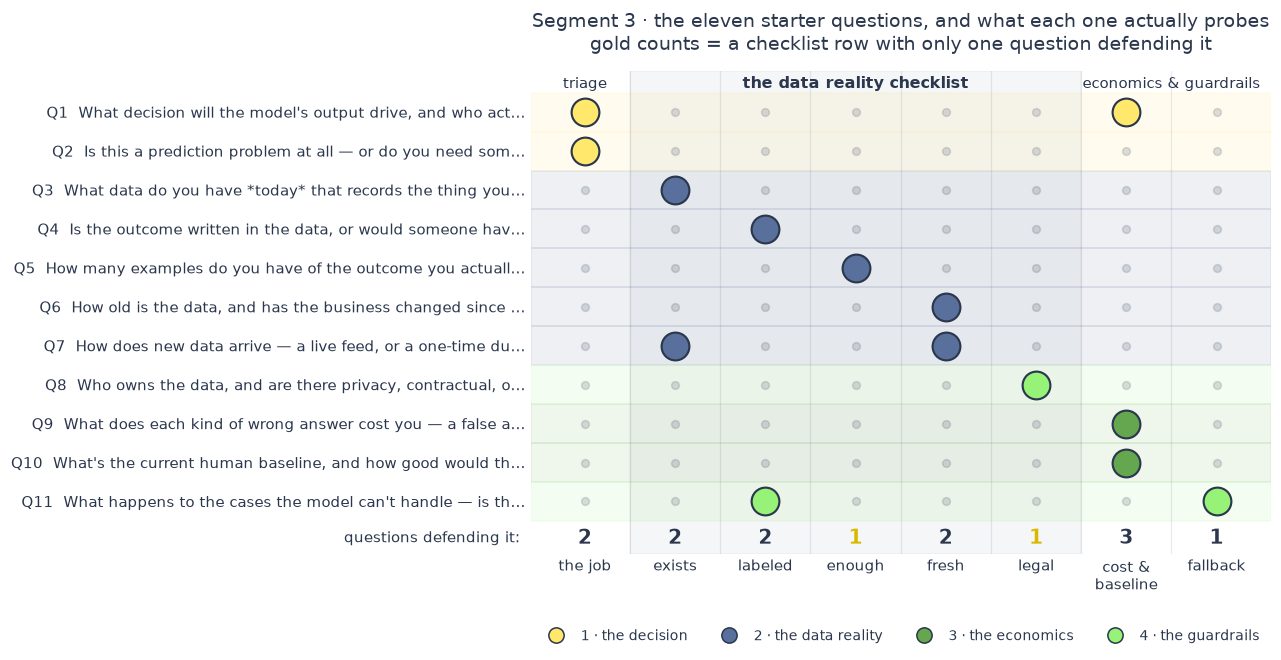

The two gold numbers at the bottom are the workshop prompt: 'enough' and 'legal' each have a
single question standing between VSP and the two most expensive failures on the checklist.
Add a question, sharpen the one that is there, or argue that one is sufficient - but decide
it on purpose, which is the only thing this figure is for.


In [17]:
# --- FIGURE 4: the bank as a coverage matrix. 11 questions down, what each one probes across.
#     This is the picture that makes task 2 a five-second decision instead of an argument.
fig, ax = plt.subplots(figsize=(11.8, 6.6))
_phase_colour = {PHASES[0]: VSP["yellow"], PHASES[1]: VSP["navy"],
                 PHASES[2]: VSP["green"], PHASES[3]: VSP["mint"]}
_top = len(BANK) - 1

for _yi, (_n, _q, _tags, _phase) in enumerate(BANK):
    _y = _top - _yi
    ax.axhspan(_y - 0.5, _y + 0.5, color=_phase_colour[_phase], alpha=0.10, zorder=0)
    for _xi, _col in enumerate(BANK_COLUMNS):
        if _col in _tags:
            ax.scatter([_xi], [_y], s=330, color=_phase_colour[_phase], edgecolor=VSP["ink"],
                       linewidth=1.4, zorder=3)
        else:
            ax.scatter([_xi], [_y], s=26, color=VSP["ink"], alpha=0.16, zorder=2)

_labels = [f"Q{_n}  " + (_q[:56] + "…" if len(_q) > 57 else _q) for _n, _q, _t, _p in BANK]
ax.set_yticks(range(_top, -1, -1), _labels, fontsize=9.5)
ax.set_xticks(range(len(BANK_COLUMNS)),
              [c.replace(" & ", " &\n") for c in BANK_COLUMNS], fontsize=9.5)
ax.set_xlim(-0.6, len(BANK_COLUMNS) - 0.4)
# Room above the top row for the group headers and below the bottom row for the counts (SI-19).
ax.set_ylim(-1.35, _top + 1.05)
for _xi in range(1, len(BANK_COLUMNS)):
    ax.axvline(_xi - 0.5, color=VSP["ink"], alpha=0.10, linewidth=0.8)
# The five checklist columns, marked off from the three that are not checklist rows.
ax.axvspan(0.5, 5.5, color=VSP["ink"], alpha=0.045, zorder=0)
ax.text(3.0, _top + 0.62, "the data reality checklist", ha="center", fontsize=10.5,
        fontweight="bold", color=VSP["ink"])
ax.text(0.0, _top + 0.62, "triage", ha="center", fontsize=9.5, color=VSP["ink"])
ax.text(6.5, _top + 0.62, "economics & guardrails", ha="center", fontsize=9.5, color=VSP["ink"])
for _col in BANK_COLUMNS:
    _qs = [n for n, _q, t, _p in BANK if _col in t]
    _xi = BANK_COLUMNS.index(_col)
    ax.text(_xi, -0.95, f"{len(_qs)}", ha="center", va="center", fontsize=13, fontweight="bold",
            color=VSP["gold_dark"] if len(_qs) == 1 and _col in CHECK_ROWS else VSP["ink"])
ax.text(-0.72, -0.95, "questions defending it:", ha="right", va="center", fontsize=9.5,
        color=VSP["ink"], clip_on=False)
_handles = [plt.Line2D([], [], marker="o", linestyle="", markersize=10,
                       markerfacecolor=_phase_colour[p], markeredgecolor=VSP["ink"], label=p)
            for p in PHASES]
ax.legend(handles=_handles, fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.13), ncols=4)
ax.set_title("Segment 3 · the eleven starter questions, and what each one actually probes\n"
             "gold counts = a checklist row with only one question defending it",
             fontsize=12.5, pad=14)
for _s in ("top", "right", "left", "bottom"):
    ax.spines[_s].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", length=0)
plt.subplots_adjust(left=0.415, right=0.985, top=0.865, bottom=0.20)
plt.show()

print("The two gold numbers at the bottom are the workshop prompt: 'enough' and 'legal' each have a")
print("single question standing between VSP and the two most expensive failures on the checklist.")
print("Add a question, sharpen the one that is there, or argue that one is sufficient - but decide")
print("it on purpose, which is the only thing this figure is for.")

In [18]:
# --- SEGMENT 3 CAPTURE: the refined bank. Fill this in DURING the last fifteen minutes. This is
#     the module's take-home artifact and the thing you apply to your own prospect for homework.
#     It never crashes when empty.

# What the room ADDED. One string per new question, in the wording the room agreed.
BANK_ADDITIONS = [
    # "How would you know, six months in, that it had stopped working - and who would notice?",
]
# What the room CUT, as (question number, why in one clause).
BANK_CUTS = [
    # (2, "the triage is our job, not a question we ask the client out loud"),
]
# What the room SHARPENED, as (question number, the new wording).
BANK_SHARPENED = [
    # (3, "Walk me through how you answer this question today, without a model. Who looks at what?"),
]
# The question you would OPEN a real discovery call with, and why (40+ characters).
OPENING_QUESTION = 0        # 1-11, or 0 if the room's opener is one of your additions
OPENING_WHY = ""

# ---------------------------------------------------------------- checker (do not edit below)
_adds = [" ".join(str(a).split()) for a in BANK_ADDITIONS if " ".join(str(a).split())]
_cuts = [(int(n), " ".join(str(w).split())) for n, w in BANK_CUTS]
_sharp = [(int(n), " ".join(str(w).split())) for n, w in BANK_SHARPENED]
_open_why = " ".join(str(OPENING_WHY).split())
try:
    _opener = int(OPENING_QUESTION or 0)
except (TypeError, ValueError):
    _opener = -1

_todo = []
if not (_adds or _cuts or _sharp):
    _todo.append("At least one of BANK_ADDITIONS / BANK_CUTS / BANK_SHARPENED - fifteen minutes of "
                 "a room's attention should change something, and 'we changed nothing' is a "
                 "finding that needs a reason.")
_todo += [f"BANK_CUTS: question {n} is not in 1-11." for n, _w in _cuts if not 1 <= n <= 11]
_todo += [f"BANK_CUTS: give a reason for cutting Q{n} (15+ characters)."
          for n, w in _cuts if len(w) < 15]
_todo += [f"BANK_SHARPENED: question {n} is not in 1-11." for n, _w in _sharp if not 1 <= n <= 11]
_todo += [f"BANK_SHARPENED: Q{n}'s new wording needs 30+ characters."
          for n, w in _sharp if len(w) < 30]
_todo += [f"BANK_ADDITIONS: '{a[:40]}...' needs 30+ characters to be a question."
          for a in _adds if len(a) < 30]
if not (0 <= _opener <= 11) or (_opener == 0 and not _adds):
    _todo.append("OPENING_QUESTION: 1-11, or 0 only if your opener is one of your own additions.")
if len(_open_why) < 40:
    _todo.append(f"OPENING_WHY: 40+ characters (you have {len(_open_why)}) - why THAT question first. "
                 f"'Because a client who cannot name the decision does not have a project' is a "
                 f"reason; 'because it is first' is not.")

rule("SEGMENT 3 - THE REFINED BANK")
_cut_ns = {n for n, _w in _cuts}
_sharp_map = dict(_sharp)
_final = []
for _n, _q, _tags, _phase in BANK:
    if _n in _cut_ns:
        continue
    _final.append((f"Q{_n}" + ("*" if _n in _sharp_map else ""), _sharp_map.get(_n, _q), _tags))
for _ix, _a in enumerate(_adds, start=1):
    _final.append((f"NEW{_ix}", _a, ["(tag it yourself)"]))
print(f"{len(_final)} questions after {len(_adds)} addition(s), {len(_cuts)} cut(s), "
      f"{len(_sharp)} sharpened (* = reworded):")
print()
for _tag, _q, _tags in _final:
    print(textwrap.fill(f"{_tag:<5} {_q}", width=104, initial_indent="  ",
                        subsequent_indent="        "))
print()
if _todo:
    for _t in _todo[:6]:
        print(textwrap.fill(f"[TODO] {_t}", width=104, subsequent_indent="       "))
    print()
    print("       Nothing saves until the bank has been changed on purpose and the opener has a")
    print("       reason. This is the module's take-home artifact - it is the thing you carry into")
    print("       ASM-1, and a bank you did not argue about is a bank you will not remember.")
else:
    for _n, _w in _cuts:
        wrap(f"CUT Q{_n}", _w)
    print(f"\nOPENS WITH: {'Q' + str(_opener) if _opener else 'one of your additions'}")
    wrap("BECAUSE", _open_why)
    _p = save_artifact("refined_bank", {
        "artifact": "the refined pre-sales question bank - MOD-1's take-home artifact",
        "starter_bank_source": "program/lessons/LSN-1.6-data-requirements-presales-question-bank.md",
        "additions": _adds,
        "cuts": [{"question": n, "why": w} for n, w in _cuts],
        "sharpened": [{"question": n, "new_wording": w} for n, w in _sharp],
        "opening_question": _opener, "opening_why": _open_why,
        "final_bank": [{"id": t, "question": q} for t, q, _tg in _final],
    })
    print(f"\n[SAVED] {_p.relative_to(REPO_ROOT)}   (stays on your machine; gitignored)")
    print("        THIS is the bank you apply to your own prospect in the homework below, and the")
    print("        one you bring to the ASM-1 mock conversation. Print it. Two sides of one page.")

                                      SEGMENT 3 - THE REFINED BANK                                      
11 questions after 0 addition(s), 0 cut(s), 0 sharpened (* = reworded):

  Q1    What decision will the model's output drive, and who acts on it?
  Q2    Is this a prediction problem at all — or do you need something generative/conversational?
        (LSN-1.1 triage)
  Q3    What data do you have *today* that records the thing you want predicted?
  Q4    Is the outcome written in the data, or would someone have to label it? Who, and at what cost?
  Q5    How many examples do you have of the outcome you actually care about — especially if it's rare?
  Q6    How old is the data, and has the business changed since it was collected?
  Q7    How does new data arrive — a live feed, or a one-time dump someone exported once?
  Q8    Who owns the data, and are there privacy, contractual, or regulatory limits on using it this
        way?
  Q9    What does each kind of wrong answer cost you 

---

# Homework — apply the bank to a prospect you know

> **The lesson plan's wording, verbatim:** *Apply the refined question bank to one prospect or project you know
> first-hand. Submit the filled bank referencing `LSN-1.6` before ASM-1.* **Pass:** *every checklist dimension
> (exists/labeled/enough/fresh/legal) addressed with specifics, plus at least one honestly-stated limitation
> ("here's where the model would break and what I'd scope instead"). This artifact is part of the ASM-1
> evidence for `OUT-1.6`.*

**Pick a prospect you know first-hand.** A live deal, a project you delivered, a client you spoke to last
month, or your own team's internal problem. **It does not have to be a construction site and it does not have
to be an ML project yet** — the point is that you know enough about the data to answer five questions with
specifics rather than adjectives. A prospect you know badly makes this homework impossible; a boring prospect
you know well makes it easy.

### What "with specifics" means, because that is the whole pass bar

| Not specifics | Specifics |
|---|---|
| "they have a lot of data" | "about 6,400 rows since the 2022 migration, in their CRM" |
| "someone would have to label it" | "the ops director would, and two of them disagreed on 3 of 12 cases" |
| "there's probably enough" | "84,000 rows, but only 310 of the outcome we care about" |
| "the data is fairly recent" | "starts March 2023, current to last month, and they repriced in April" |
| "we'd need to check the legal side" | "they own it under the MSA, but faces are identifiable in a third of the frames" |

**The right-hand column is not longer. It is checkable.** A client could confirm or correct every one of those,
and that is the test: **if nobody could disagree with your answer, it is not an answer.**

### And the limitation, which is the row `ASM-1` grades hardest

*"Here's where the model would break and what I'd scope instead."* **Both halves.** A limitation without an
alternative is a reason to walk away; a limitation *with* an alternative is a scoped project. `LSN-1.5`'s
rubric called this row *honest boundary* and it is graded in `ASM-1` under the name
*honesty-about-limitations* — the same skill, on paper this time.

### This notebook is the template's home

> **The question-bank template** is a `GAP-5` build item in the lesson plan's Materials table ("*Question bank
> template (blank, for homework submissions) — derive from the refined session output*"). **It is built, and
> the next cell is it.** Status, honestly stated: this is the **starter template — refined live at delivery,
> and the template gets updated after the first delivery** from what the room actually produces in segment 3.
> The blank version is here so that homework can be submitted on day one; the refined version replaces the
> starter bank in this notebook after delivery 1.

**The advisor below is a pre-check, not the grader.** Tyler reads the actual submission. What the advisor can
do is catch the three ways this homework comes back: an answer that is not specific, an answer that is
answering a different row, and a limitation with no alternative. Run it before you submit and you will not get
it back.

In [19]:
# --- THE HOMEWORK ADVISOR. It pre-checks the pass bar: five checklist rows "addressed with
#     specifics" + one honestly-stated limitation with an alternative. It is NOT the grader.
#
#     HOW IT WORKS, and why it is not a keyword list. A good answer to any of these rows has a
#     recognisable SHAPE regardless of industry: it contains at least one thing a client could
#     check (a count, a named system, a named role, a date) and it is genuinely about the row it
#     is in. So the advisor looks for five FAMILIES of specificity - numbers, named things, roles,
#     times, systems - plus per-row topic cues, and it demotes answers that hedge or defer instead
#     of answering. Every probe is word-boundary matched (LL-30) and counted by distinct matched
#     word (LL-35), and the whole thing is tested on four planted answers at the bottom (SI-26c).

# ---- family 1: quantities. Digits, and the written magnitudes people use instead.
MAGNITUDES = ["hundreds", "thousands", "millions", "dozens", "a dozen", "half a dozen"]
NUM_RX = re.compile(r"\b\d[\d,]*(?:\.\d+)?\s*%?")

# ---- family 2: named things - systems, tools, companies, regulations, places. A SHAPE probe, not
#      a keyword list: an acronym anywhere, or a capitalised word that is not sentence-initial.
CAP_RX = re.compile(r"\b[A-Z][A-Za-z0-9&./+-]{1,}\b")
CAP_STOP = {"I", "We", "The", "They", "It", "But", "And", "So", "If", "Our", "Their", "There",
            "This", "That", "Also", "Then", "Yes", "No", "Not", "A", "An", "As", "At", "By",
            "For", "From", "He", "Her", "His", "How", "In", "Is", "My", "Of", "On", "One",
            "Or", "She", "Some", "Than", "These", "Those", "To", "Two", "Up", "What", "When",
            "Where", "Which", "Who", "Why", "With", "You", "Your", "Nobody", "Nothing",
            "Everyone", "Every", "Each", "Both", "All", "Most", "More", "Less", "Only",
            "Because", "Before", "After", "Since", "Until", "While", "About", "Above",
            "Would", "Could", "Should", "Will", "Can", "Cannot", "Do", "Does", "Did", "Has",
            "Have", "Had", "Was", "Were", "Am", "Are", "Be", "Been", "Being", "Right", "Left",
            "First", "Second", "Third", "Last", "Next", "Now", "Today", "Yesterday", "Legal",
            "Data", "Labels", "Label", "Fresh", "Enough", "Exists", "Labeled", "Labelled"}
# ML jargon in caps is not a named thing - it is us talking to ourselves.
ACRONYM_STOP = {"AI", "ML", "DL", "NN", "CNN", "RNN", "LSTM", "GAN", "LLM", "MLP", "SGD",
                "ROC", "AUC", "TBD", "OK", "ASAP", "FYI", "ETC", "AKA", "EG", "IE"}

# ---- family 3: roles. "Who" is answered with a job, almost never with a name.
ROLE_WORDS = ["manager*", "foreman", "foremen", "superintendent*", "director*", "supervisor*",
              "engineer*", "analyst*", "admin*", "operator*", "technician*", "inspector*",
              "coordinator*", "estimator*", "scheduler*", "dispatcher*", "controller*",
              "project manager*", "site lead*", "team lead*", "pm", "pms", "ops", "crew*",
              "subcontractor*", "contractor*", "client*", "customer*", "vendor*", "recruiter*",
              "underwriter*", "broker*", "agent*", "nurse*", "clinician*", "surveyor*",
              "accountant*", "bookkeeper*", "planner*", "quantity surveyor*", "cto", "cfo", "coo",
              "ceo", "vp", "head of*", "owner*", "partner*", "auditor*", "reviewer*", "labeller*",
              "labeler*", "annotator*", "our team", "their team", "my team"]

# ---- family 4: time. Dates, ages and cadences.
TIME_WORDS = ["today", "yesterday", "last year", "last month", "last quarter", "last week",
              "this year", "since", "ago", "daily", "nightly", "weekly", "monthly", "quarterly",
              "annually", "hourly", "real time", "real-time", "per day", "per week", "per month",
              "as of", "up to date", "out of date", "recent*", "stale", "current*", "january",
              "february", "march", "april", "may", "june", "july", "august", "september",
              "october", "november", "december", "20*", "19*"]

# ---- family 5: systems. Where the data physically lives.
SYSTEM_WORDS = ["database*", "spreadsheet*", "excel", "csv", "sql", "crm", "erp", "api", "s3",
                "sharepoint", "dropbox", "google drive", "shared drive", "onedrive", "one drive",
                "folder*", "server*", "log", "logs", "logfile*", "ticket*", "work order*", "pdf*",
                "email*", "inbox", "app", "portal", "dashboard*", "data lake", "data warehouse",
                "warehouse", "table*", "record*", "export*", "photo*", "image*", "video*",
                "scan*", "form*", "report*", "invoice*", "timesheet*", "drone footage",
                "camera*", "sensor*", "notebook*", "whatsapp", "slack", "teams",
                "jira", "procore", "sap", "salesforce", "hubspot", "quickbooks", "autocad",
                "bim", "gps", "iot", "pos"]


def named_things(text: str) -> list:
    """Named systems, tools, companies, regulations, places - by SHAPE, not by dictionary.

    An all-caps acronym anywhere (MSA, GDPR, Procore's caps siblings), or a capitalised token
    that is NOT the first word of its sentence. Sentence-initial capitals are dropped, so
    "They have photos" contributes nothing at all.
    """
    out = []
    for _sentence in re.split(r"(?<=[.!?;:])\s+|\n+", str(text)):
        _toks = _sentence.split()
        for _ix, _tok in enumerate(_toks):
            _core = _tok.strip("\"'()[]{},.;:!?")
            if not _core or _core in CAP_STOP:
                continue
            if re.fullmatch(r"[A-Z]{2,6}s?", _core):
                if _core.upper().rstrip("S") in ACRONYM_STOP:
                    continue
                out.append(_core)
            elif _ix > 0 and CAP_RX.fullmatch(_core) and _core[1:] != _core[1:].upper():
                out.append(_core)
    _seen, _uniq = set(), []
    for _w in out:
        if _w.lower() not in _seen:
            _seen.add(_w.lower())
            _uniq.append(_w)
    return _uniq


def families(text: str) -> dict:
    """The five kinds of specific, and which of them this answer contains."""
    t = " ".join(str(text).split())
    return {"numbers": NUM_RX.findall(t) + probe_spans(t, MAGNITUDES),
            "named":   named_things(t),
            "roles":   probe_spans(t, ROLE_WORDS),
            "time":    probe_spans(t, TIME_WORDS),
            "systems": probe_spans(t, SYSTEM_WORDS)}


# ---- per-row topic cues: is this answer actually about THIS row?
ROW_CUES = {
    "exists": ["record*", "stored", "store*", "exist*", "captur*", "collect*", "log", "logs",
               "logged", "track*", "written down", "no data", "not captured", "keep*", "kept",
               "archiv*", "we have", "they have", "database*", "spreadsheet*", "file*", "photo*",
               "their system*", "our system*", "the system", "today", "currently", "lives in",
               "sits in", "goes into", "written into", "anywhere", "nowhere", "verbal*",
               "informal*", "on paper", "in someone's head", "in people's heads", "memory",
               "phone", "email*", "whiteboard", "is in", "are in", "held in", "stored in",
               "sits with", "ends up in", "every", "not recorded", "never written",
               "nobody writes"],
    "labeled": ["rate", "rated", "rating*", "score*", "scored", "written in", "would need",
                "differently", "each of", "minutes each", "who would", "somebody", "someone",
                "human", "assess*", "grade*", "classif*", "adjudicat*", "verif*", "confirm*",
                "inter-rater", "double", "twice", "per photo", "per case", "per record",
                "label*", "annotat*", "tag*", "mark*", "who decides", "decides", "judgement",
                "judgment", "agree*", "disagree*", "sign off", "signs off", "sign-off",
                "review*", "ground truth", "gold", "rater*", "consisten*", "inconsisten*",
                "definition*", "criteri*", "outcome is written", "someone would have to",
                "by hand", "manual*", "per label", "cost per"],
    "enough": ["how many", "examples", "rows", "records", "count*", "per", "rare", "rarely",
               "class*", "base rate", "volume", "sample*", "at least", "minimum", "imbalanc*",
               "only", "each", "photos", "cases", "instances", "events", "occurrence*",
               "positives", "negatives", "of them", "of those", "of these", "out of", "total",
               "across", "roughly", "about", "approximately", "around", "a year", "a month",
               "per year", "per month", "handful"],
    "fresh": ["recent*", "old", "older", "age", "aged", "stale", "chang*", "since", "drift*",
              "updat*", "month*", "year*", "quarter*", "week*", "day*", "reorg*", "season*",
              "new", "current*", "no longer", "live", "feed", "batch", "one-time", "one off",
              "one-off", "dump", "export*", "refresh*", "ongoing", "arrive*"],
    "legal": ["own*", "privacy", "private", "consent", "contract*", "regulat*", "complian*",
              "gdpr", "ccpa", "hipaa", "pii", "personal data", "licen*", "rights", "legal",
              "nda", "confidential*", "anonymi*", "anonymous", "face*", "identifiab*",
              "identify*", "subcontract*", "msa", "dpa", "permission*", "allowed", "may we",
              "data processing", "retention", "jurisdiction*", "union*", "works council"],
}
ROW_ADVICE = {
    "exists": "name the system it lives in and say what is NOT recorded today",
    "labeled": "name who would label it, and what one label costs in time or money",
    "enough": "give the count of the outcome you care about, not the count of rows",
    "fresh": "give the age of the data AND what changed in the business since",
    "legal": "say who owns it and name the one limit that would surface in legal review",
}
# The specificity a row REQUIRES. "Enough" is a how-many question, so a count IS the answer;
# "fresh" is a how-old question, so a date or a cadence is. The other three are answered with
# names - "who owns it" and "where does it live" are not numeric questions.
ROW_REQUIRED = {"enough": ("numbers", "a count - 'how many' is the question this row asks"),
                "fresh":  ("time", "a date or a cadence - 'how old' is the question this row asks")}

# Hedging is not specificity, and deferring is not answering.
VAGUE_WORDS = ["some", "a lot", "lots", "plenty", "probably", "i think", "i guess", "maybe",
               "not sure", "unsure", "tbd", "n/a", "stuff", "various", "etc", "quite a few",
               "should be fine", "no idea", "unclear", "somewhere", "or so", "roughly speaking"]
DEFERRALS = ["would need to check", "need to check", "have to check", "worth checking",
             "we would ask", "have to ask", "haven't asked", "have not asked", "not sure",
             "don't know", "do not know", "no idea", "to be confirmed", "tbd",
             "need to find out", "would need to look", "would have to look", "unclear",
             "there might be", "there could be", "have to find out"]

# ---- the limitation row: where it breaks, AND what you would scope instead.
LIMIT_WORDS = ["can't", "cannot", "can not", "won't", "will not", "would not", "wouldn't",
               "does not", "doesn't", "do not", "don't", "break*", "fail*", "wrong", "risk*",
               "limit*", "weak*", "not enough", "too few", "too little", "unreliable",
               "no guarantee", "never", "hard to", "expensive", "sensitive to", "ambiguous",
               "unknown", "we would need", "we'd need", "assum*", "only", "miss*", "false",
               "degrade*", "drift*", "noisy", "gap", "gaps", "blind spot*", "edge case*",
               "struggle*", "worse", "confus*", "over-promis*", "overpromis*", "might not",
               "may not", "not perfect", "issue*", "problem*", "caveat*", "trade-off*",
               "tradeoff*"]
SCOPE_WORDS = ["pilot", "phase*", "start with", "begin with", "one", "single", "narrow*",
               "scope*", "scoped", "instead", "human in the loop", "human-in-the-loop",
               "human review", "manual review", "review step", "fallback", "fall back",
               "escalat*", "flag for", "first", "smaller", "subset", "proof of concept",
               "poc", "trial", "limited to", "just the", "only the", "before we", "then expand",
               "baseline", "shadow mode", "assist*", "recommend*", "co-pilot", "copilot"]

MIN_DIMENSION, MIN_LIMIT, MIN_SCOPE, MIN_PROSPECT = 60, 60, 40, 12


def advise_row(row: str, text: str) -> tuple:
    """Score one checklist row 0/1/2 against the pass bar. Returns (score, why, detail)."""
    t = " ".join(str(text).split())
    hit = [k for k, v in families(t).items() if v]
    cues = sorted(set(probe_spans(t, ROW_CUES[row])))
    vague = probe(t, VAGUE_WORDS)
    defer = probe(t, DEFERRALS)
    detail = {"families": hit, "cues": cues, "vague": vague, "defers": defer, "chars": len(t)}
    if len(t) < MIN_DIMENSION:
        return 0, (f"{len(t)} characters - under the {MIN_DIMENSION}-character floor. "
                   f"{ROW_ADVICE[row]}."), detail
    if not hit and not cues:
        return 0, f"nothing specific and nothing on-topic - {ROW_ADVICE[row]}.", detail
    if not cues:
        return 1, (f"specific ({', '.join(hit)}) but it reads like an answer to a different row - "
                   f"{ROW_ADVICE[row]}."), detail
    if not hit:
        return 1, (f"on-topic ({', '.join(cues[:3])}) but nothing a client could check - "
                   f"{ROW_ADVICE[row]}."), detail
    if len(cues) < 2:
        return 1, (f"specific ({', '.join(hit)}) but only glances at this row ('{cues[0]}') - "
                   f"{ROW_ADVICE[row]}."), detail
    need = ROW_REQUIRED.get(row)
    if need and need[0] not in hit:
        return 1, f"specific ({', '.join(hit)}) and on-topic, but this row needs {need[1]}.", detail
    if defer and len(hit) < 3:
        return 1, (f"defers instead of answering ('{defer[0]}'). \"Nobody has asked yet\" is a fine "
                   f"answer - say who you would ask and when, and it becomes one."), detail
    if len(vague) >= 2 or (vague and len(hit) < 2):
        return 1, (f"on-topic but hedged ({', '.join(vague[:3])}) with only {len(hit)} kind(s) of "
                   f"specific - {ROW_ADVICE[row]}."), detail
    return 2, (f"specifics ({', '.join(hit)}) + genuinely on this row "
               f"({', '.join(cues[:3])})."), detail


def advise_limitation(limit_text: str, scope_text: str) -> tuple:
    """Score the limitation + alternative as one row: 'where it breaks AND what I'd scope instead'."""
    lt, st = " ".join(str(limit_text).split()), " ".join(str(scope_text).split())
    lim = sorted(set(probe_spans(lt, LIMIT_WORDS)))
    lfam = [k for k, v in families(lt).items() if v]
    sc = sorted(set(probe_spans(st, SCOPE_WORDS)))
    detail = {"limit_words": lim, "limit_families": lfam, "scope_words": sc,
              "chars": (len(lt), len(st))}
    has_break = len(lt) >= MIN_LIMIT and bool(lim) and bool(lfam)
    has_scope = len(st) >= MIN_SCOPE and bool(sc)
    if has_break and has_scope:
        return 2, (f"names where it breaks ({', '.join(lim[:3])}, grounded in "
                   f"{', '.join(lfam)}) AND what you would scope instead "
                   f"({', '.join(sc[:3])})."), detail
    if has_break:
        return 1, ("names the breaking point but not the alternative. \"It would break\" loses the "
                   "deal; \"it would break, so I would scope X first\" wins it."), detail
    if lim and len(lt) >= MIN_LIMIT and not lfam:
        return 0, (f"hedges ({', '.join(lim[:3])}) without naming a condition a client could "
                   f"check. \"It might not be perfect\" is not a limitation; \"it breaks on the "
                   f"310 confirmed cases\" is."), detail
    if has_scope:
        return 1, ("proposes a scope but never says what would break - a pilot without a stated "
                   "failure mode reads like a discount, not judgement."), detail
    return 0, ("no honest limitation. This is the row ASM-1 grades hardest, and the row that makes "
               "a client believe the other five."), detail


def bank_report(label: str, answers: dict) -> tuple:
    """Print one full pre-check report and return (row scores, limitation score, verdict)."""
    _scores, _rows_total = {}, 0
    print(f"\n{label}")
    for _row in CHECK_ROWS:
        _s, _why, _d = advise_row(_row, answers.get(_row, ""))
        _scores[_row] = _s
        _rows_total += _s
        wrap(f"{_s}/2 {_row.upper()}", _why, width=104, pad=20)
    _ls, _lwhy, _ld = advise_limitation(answers.get("limitation", ""), answers.get("scope", ""))
    wrap(f"{_ls}/2 LIMITATION", _lwhy, width=104, pad=20)
    _pass = _rows_total == 10 and _ls == 2
    wrap("VERDICT", f"{_rows_total}/10 on the five rows + {_ls}/2 on the limitation = "
                    f"{_rows_total + _ls}/12. "
                    + ("PASS on the pre-check - every dimension addressed with specifics and a "
                       "limitation with an alternative."
                       if _pass else
                       "NOT YET. The pass bar is every dimension at 2 and the limitation at 2; "
                       + ", ".join(f"{r} ({s}/2)" for r, s in _scores.items() if s < 2)
                       + (" and the limitation" if _ls < 2 else "") + " still short."),
         width=104, pad=20)
    return _scores, _ls, _pass


# ================================================================ the advisor, tested (SI-26c)
# Four planted submissions. Two of them PASS and two FAIL, and the two that pass are from
# completely different industries on purpose: if the probes were secretly a construction-word
# list, the insurance one would fail, and that would be a bug worth finding here rather than in
# somebody's homework.
PLANTED = {
    "STRONG - construction (a real answer, trimmed)": {
        "exists": "Yes - every completed work order in Procore carries a closeout photo set, about "
                  "40 photos per unit, going back to the 2023 turnover of Tower B. What is NOT "
                  "recorded is the milestone name; the superintendent types it into a free-text note.",
        "labeled": "Nobody labels it today. The superintendent decides what \"framing complete\" "
                   "means and signs it off in the daily report; two superintendents on the same "
                   "unit disagreed on 3 of 12 milestones last quarter. A label costs about 45 "
                   "seconds of a $85/hour person.",
        "enough": "About 1,200 closeout photo sets across 8 buildings, but only 96 of them cover "
                  "the rare milestone the client actually cares about - MEP rough-in sign-off. "
                  "That is 96 examples of the outcome, not 1,200.",
        "fresh": "The photo archive starts in March 2023 and is current to last month, but the "
                 "client moved to prefab panel framing in January, so every pre-2026 photo shows "
                 "a construction method that no longer exists on their sites.",
        "legal": "The client owns the photos under the MSA, but subcontractor crews are "
                 "identifiable in roughly a third of the frames and the union agreement bans using "
                 "site imagery for performance monitoring. Their counsel would have to sign off.",
        "limitation": "It would break on the rare milestones: with 96 examples of MEP rough-in the "
                      "model is in the region where our own MNIST curve gave 64%, and that was on "
                      "clean centred digits. Camera angle changes between crews make it worse.",
        "scope": "So I would scope a pilot on one milestone type - slab pour, where we have 400 "
                 "examples - with the superintendent reviewing every prediction for the first month.",
        "expect": ((2, 2, 2, 2, 2), 2),
    },
    "STRONG - insurance (a different industry entirely)": {
        "exists": "Yes. Every claim since the Guidewire migration in 2022 sits in their claims "
                  "table with the adjuster's final settlement amount, roughly 84,000 closed "
                  "claims. Nothing records WHY a claim was escalated - that lives in free-text "
                  "adjuster notes.",
        "labeled": "The settlement outcome is written in the data, so no labelling for the amount. "
                   "But \"was this claim fraudulent\" is not recorded - only the special "
                   "investigations unit knows, and a senior investigator would have to review each "
                   "file, about 20 minutes apiece.",
        "enough": "84,000 closed claims in total, but only 310 of them were referred to "
                  "investigations and confirmed fraudulent. So the outcome we care about has 310 "
                  "examples, roughly 0.4% of the rows - a base rate that will make accuracy useless.",
        "fresh": "The claims table is current to yesterday and refreshes nightly, but they repriced "
                 "their commercial book in April and changed the escalation threshold, so anything "
                 "before 2025 was generated under different rules.",
        "legal": "They own the claims data, but it is full of personal medical detail, so anything "
                 "we build has to stay inside their tenancy, and their DPA with us would need "
                 "amending before a single row leaves the building.",
        "limitation": "It breaks on fraud. With 310 confirmed cases we are far to the left of the "
                      "data curve, and a model that never flags fraud would still score 99.6% "
                      "accurate - which is the trap we showed in the metrics session.",
        "scope": "So I would scope phase one as settlement-amount estimation, where the label "
                 "already exists, and hold fraud back until they can give us a labelled history.",
        "expect": ((2, 2, 2, 2, 2), 2),
    },
    "THIN - the shape most first attempts come back in": {
        "exists": "They have some photos on a shared drive from the last couple of years, I think "
                  "there are quite a few.",
        "labeled": "Someone would have to label the photos. It would probably take a while and cost "
                   "money to do.",
        "enough": "They probably have enough photos to train something, we would have to look at "
                  "the volume.",
        "fresh": "The data is reasonably recent I think, nothing much has changed at the company "
                 "recently.",
        "legal": "We would need to check the legal side, there might be privacy issues with the "
                 "photos.",
        "limitation": "The model might not work perfectly and there could be some issues with "
                      "accuracy on hard cases.",
        "scope": "We would start small and see how it goes.",
        "expect": ((1, 1, 1, 1, 1), 0),
    },
    "WRONG - answering about the MODEL instead of the DATA": {
        "exists": "We would use a convolutional neural network with several layers because CNNs are "
                  "the best architecture for image classification tasks in production systems.",
        "labeled": "The model outputs a probability between 0 and 1 and we would set the threshold "
                   "at 0.5 to decide whether the milestone counts as complete.",
        "enough": "Deep learning is a subset of machine learning and it learns its own features "
                  "from the raw pixels instead of being handed them.",
        "fresh": "Accuracy is the wrong metric here so we would look at precision and recall "
                 "instead, plus the confusion matrix.",
        "legal": "We would deploy it on AWS with a REST API and monitor the latency with a dashboard.",
        "limitation": "It will be very accurate and the client will be happy with the results we "
                      "deliver.",
        "scope": "We can build the whole thing.",
        "expect": ((1, 1, 0, 0, 1), 0),
    },
}

rule("THE ADVISOR, TESTED ON FOUR PLANTED SUBMISSIONS BEFORE IT GOES NEAR YOURS  (SI-26c)")
for _label, _answers in PLANTED.items():
    _expect_rows, _expect_limit = _answers["expect"]
    _scores, _limit, _pass = bank_report(_label, _answers)
    assert tuple(_scores[r] for r in CHECK_ROWS) == _expect_rows, (_label, _scores)
    assert _limit == _expect_limit, (_label, _limit)
print()
rule()
print("All four verdicts are asserted, not asserted-at. Read the THIN one closely, because it is")
print("what this homework actually comes back looking like: nothing in it is false, every row is")
print("about the right topic, and not one line could be confirmed or corrected by a client. That is")
print("the difference the pass bar is measuring.")
print()
print("AND THE ADVISOR'S OWN HONEST LIMITATION, which is on-brand for this lesson: it reads shape,")
print("not truth. A deliberately keyword-stuffed answer - \"records, database, the manager, 2024,")
print("1,200 examples, GDPR\" - scores 12/12 and says nothing. It is a pre-check for the three ways")
print("this homework comes back wrong, not a grader. Tyler reads the submission; ASM-1 grades the")
print("conversation. What gaming it costs you is the only thing that matters: a word salad instead")
print("of a discovery call, one week before somebody plays the client for real.")

          THE ADVISOR, TESTED ON FOUR PLANTED SUBMISSIONS BEFORE IT GOES NEAR YOURS  (SI-26c)           

STRONG - construction (a real answer, trimmed)
  2/2 EXISTS        specifics (numbers, named, roles, time, systems) + genuinely on this row (every, not
                    recorded, photo).
  2/2 LABELED       specifics (numbers, roles, time, systems) + genuinely on this row (decides,
                    disagree, label).
  2/2 ENOUGH        specifics (numbers, named, roles, time, systems) + genuinely on this row (about,
                    across, examples).
  2/2 FRESH         specifics (numbers, named, roles, time, systems) + genuinely on this row (current,
                    month, no longer).
  2/2 LEGAL         specifics (named, roles, systems) + genuinely on this row (identifiab, msa, own).
  2/2 LIMITATION    names where it breaks (break, worse, grounded in numbers, named, roles, systems) AND
                    what you would scope instead (first, one, pilot).
  VERDICT  

In [20]:
# --- THE QUESTION-BANK TEMPLATE (blank). This is the GAP-5 "question bank template (blank, for
#     homework submissions)" Materials item, and this cell is its canonical home.
#     STATUS: starter template - refined live at delivery, template updated after first delivery.
#
#     Fill it in for ONE prospect you know first-hand, run the cell, read the advisor, fix the
#     rows it flags, run it again. It never crashes when empty.

# ---- who and what (Q1 of the bank: the decision is what makes the rest matter)
PROSPECT = ""          # the client / project, anonymised however you like ("a mid-size 3PL")
THE_DECISION = ""      # what decision the output would drive, and who acts on it (60+ chars)

# ---- the five checklist rows. Specifics, not adjectives (60+ characters each).
EXISTS = ""     # Is the thing you want predicted actually recorded anywhere today? Where?
LABELED = ""    # Does each example carry the answer, or must a human add it? Who, at what cost?
ENOUGH = ""     # How many examples - especially of the RARE outcome? (a count is required here)
FRESH = ""      # How recent, and what changed in the business since? (a date or cadence required)
LEGAL = ""      # Do you own it, and may you use it this way? Privacy, contract, people in frame?

# ---- the limitation, in two halves. Both halves are the pass bar.
LIMITATION = ""       # where the model would break, and under what condition (60+ chars)
SCOPED_INSTEAD = ""   # ... and what you would scope instead (40+ chars)

# ---------------------------------------------------------------- checker (do not edit below)
MY_BANK = {"exists": EXISTS, "labeled": LABELED, "enough": ENOUGH, "fresh": FRESH, "legal": LEGAL,
           "limitation": LIMITATION, "scope": SCOPED_INSTEAD}
_prospect = " ".join(str(PROSPECT).split())
_decision = " ".join(str(THE_DECISION).split())
_clean = {k: " ".join(str(v).split()) for k, v in MY_BANK.items()}

_todo = []
if len(_prospect) < MIN_PROSPECT:
    _todo.append(f"PROSPECT: {MIN_PROSPECT}+ characters (you have {len(_prospect)}). Anonymise it "
                 f"however you like, but name it - \"a client\" is not a prospect you know.")
if len(_decision) < MIN_DIMENSION:
    _todo.append(f"THE_DECISION: {MIN_DIMENSION}+ characters (you have {len(_decision)}). Question 1 "
                 f"of the bank, and the one that decides whether the project is worth doing: what "
                 f"changes once they know, and who does it?")
for _row in CHECK_ROWS:
    if len(_clean[_row]) < MIN_DIMENSION:
        _todo.append(f"{_row.upper()}: {MIN_DIMENSION}+ characters (you have {len(_clean[_row])}). "
                     f"{ROW_ADVICE[_row].capitalize()}.")
if len(_clean["limitation"]) < MIN_LIMIT:
    _todo.append(f"LIMITATION: {MIN_LIMIT}+ characters (you have {len(_clean['limitation'])}). Where "
                 f"would it break, and under what condition? A number makes this checkable.")
if len(_clean["scope"]) < MIN_SCOPE:
    _todo.append(f"SCOPED_INSTEAD: {MIN_SCOPE}+ characters (you have {len(_clean['scope'])}). The "
                 f"second half of the pass bar - what you would scope instead.")

if _todo:
    rule("YOUR QUESTION BANK - not ready to submit yet")
    for _t in _todo:
        print(textwrap.fill(f"[TODO] {_t}", width=104, subsequent_indent="       "))
    print()
    print("       Nothing saves until all eight are in - and the advisor below runs on whatever you")
    print("       have written, so you can iterate before anybody reads it.")
else:
    rule(f"YOUR QUESTION BANK - {_prospect}")
    wrap("PROSPECT", _prospect, width=104, pad=16)
    wrap("THE DECISION", _decision, width=104, pad=16)
    print()
    for _row in CHECK_ROWS:
        wrap(_row.upper(), _clean[_row], width=104, pad=16)
    wrap("LIMITATION", _clean["limitation"], width=104, pad=16)
    wrap("... SCOPE", _clean["scope"], width=104, pad=16)

# ---- the pre-check, on whatever is written, filled in or not
print()
_scores, _limit, _passed = bank_report(
    "THE PRE-CHECK ON YOUR SUBMISSION" + ("" if not _todo else "  (on what you have so far)"),
    _clean)
if not _todo:
    _p = save_artifact("question_bank_homework", {
        "artifact": "LSN-1.6 homework - the pre-sales question bank applied to a known prospect",
        "template_status": "starter template - refined live at delivery, template updated after "
                           "first delivery",
        "prospect": _prospect, "the_decision": _decision,
        "checklist": {r: _clean[r] for r in CHECK_ROWS},
        "limitation": _clean["limitation"], "scoped_instead": _clean["scope"],
        "precheck": {"row_scores": _scores, "limitation_score": _limit,
                     "row_total": sum(_scores.values()), "passes_precheck": bool(_passed)},
    })
    print()
    print(f"[SAVED] {_p.relative_to(REPO_ROOT)}   (stays on your machine; gitignored)")
    print("        Submit this referencing LSN-1.6 before ASM-1. It is ASM-1 evidence for OUT-1.6,")
    print("        and the mock conversation will ask you about the row you scored lowest.")

                              YOUR QUESTION BANK - not ready to submit yet                              
[TODO] PROSPECT: 12+ characters (you have 0). Anonymise it however you like, but name it - "a client" is
       not a prospect you know.
[TODO] THE_DECISION: 60+ characters (you have 0). Question 1 of the bank, and the one that decides
       whether the project is worth doing: what changes once they know, and who does it?
[TODO] EXISTS: 60+ characters (you have 0). Name the system it lives in and say what is not recorded
       today.
[TODO] LABELED: 60+ characters (you have 0). Name who would label it, and what one label costs in time
       or money.
[TODO] ENOUGH: 60+ characters (you have 0). Give the count of the outcome you care about, not the count
       of rows.
[TODO] FRESH: 60+ characters (you have 0). Give the age of the data and what changed in the business
       since.
[TODO] LEGAL: 60+ characters (you have 0). Say who owns it and name the one limit that would surface

### What a pass looks like — an illustrative filled bank

*Two worked examples are planted in the advisor cell above and printed with their scores: one construction
prospect and one insurance prospect. **Both are illustrative — neither is a real VSP client, and the
construction one is not the `GAP-5` case brief.*** Read them for **shape**, not content. Four things every
strong answer does, and none of them require more words:

1. **It names a system, a date, a role or a count** — something the client could confirm or correct. If nobody
   could disagree with your sentence, it is not an answer.
2. **It says what is *not* there.** "What is NOT recorded is the milestone name." "Nothing records *why* a claim
   was escalated." The gap is the finding; the presence of data is not.
3. **It separates the count of rows from the count of the outcome.** *"84,000 closed claims… only 310
   confirmed fraudulent."* That one sentence is `LSN-0.3` and `LSN-1.3` and `LSN-1.4` in a single line, and it
   is the single most valuable habit in this hour.
4. **It ends in a scope, not a shrug.** "So I would scope phase one as settlement-amount estimation, where the
   label already exists, and hold fraud back."

**One thing to notice about the insurance example, because it is the transferable move.** It refuses the
client's headline problem (fraud) and proposes the adjacent one (settlement amount) **on the grounds that the
label already exists.** That is not a downgrade — it is the only version of the project that ships, and it comes
with a named condition for unlocking the version the client asked for. **That sentence is what `OUT-1.6`
actually is.**

---

## Wrap-up — `OUT-1.6`, and what `ASM-1` does with it

**You can now run a data-reality conversation with a prospect, from the ask to a scoped promise, without
over-promising.** Specifically:

- **name the five checks from memory** — *exists / labeled / enough / fresh / legal* — and say the failure each
  one catches, because the failure is what makes a client answer the question;
- **say why every "no" is a scoping conversation and not a dealbreaker**, with the five-row translation table
  behind it: a `Labeled` no is a work package, an `Enough` no is a pilot on the sub-problem, a `Fresh` no is a
  monitoring cadence;
- **put a number on `Labeled`** — that two honest people agreeing **82%** of the time is κ = **0.60**, that one
  manager signed off **1.58×** as much work as the other on the same photos, and that a model trained on one of
  them reported the site **+8.0 points** more complete than it was;
- **put your own number on `Enough`** — the curve you trained: **23.88% → 53.38% → 64.41% → 84.23% → 92.77% →
  97.04%**, why the count that matters is the count of the *rare* outcome, and why 10× the data is 10× the
  labelling cost for a roughly constant number of points;
- **put a number on `Fresh`** — accuracy **92.00% → 66.50%** while confidence went **90.12% → 90.72%**, and
  therefore: *a model cannot tell you the world changed, so the answer to "how do we know it still works" is a
  person, a cadence and a line item*;
- **ask the `Legal` row in week one**, and name the clause engineers forget: people are identifiable in frame,
  which is a legal threshold that has nothing to do with who owns the file;
- **run the five-step walkthrough on a live prospect** — restate, triage, checklist, where it breaks, what we
  promise — and land on the scoped sentence: **a pilot on one milestone type with human-in-the-loop review**,
  never *"AI that watches your sites"*;
- **and hold the bank**: eleven questions, refined by the room, ordered the way a discovery call flows, with
  your own reason for what you open with.

### What `ASM-1` asks you for

| `ASM-1` component | What this lesson gave you |
|---|---|
| **Async quiz** (~15 scenario questions, 30 min) | the five checks, the failure each catches, the rare-class arithmetic, and the difference between accuracy and usefulness |
| **Live mock pre-sales conversation** (15 min, Vlad or Dorel plays the client) | the walkthrough, run out loud. The rubric dimension called *honesty-about-limitations* is this lesson's entire second half |
| **The question-bank artifact** | your filled homework bank — direct evidence for `OUT-1.6` |
| **Pass bar** | quiz 80% + rubric "client-ready" on **triage** and **honesty-about-limitations** |

**Both `ASM-1` rubric dimensions were built in this module, and this lesson owns the second one.** *Triage* was
`LSN-1.1`. *Honesty about limitations* is the checklist, the walkthrough's step 4, and the limitation row of
your homework. If you are wondering what to rehearse: **rehearse saying a "no" that sounds like a plan.**

### The sentence to leave `MOD-1` with

> *"Before we talk about what the model could do — can I ask five questions about your data? Because if the
> answer to any of them is 'no', that's not a problem, it's the first phase of the project, and I'd rather
> price it now than discover it in month four."*

Nobody has ever lost a deal to that sentence. Several have been lost to its absence. **`MOD-2` starts next
week** — `LSN-2.1`, how LLMs actually work — and the first thing it will ask you to do is notice that a
language model has a data-reality checklist too, and that it is a different one.

In [21]:
# --- WHAT THIS LESSON CITES, verified on disk (SI-6 / SI-26a: read what you cite). Four
#     citations, three of them notebooks this cohort ran, one of them the plan itself. A citation
#     is a claim, so the claim is checked rather than assumed.
CITATIONS = {
    "LSN-1.4 - the degradation curve this lesson opens on":
        "notebooks/lessons/LSN-1.4_Hands_On_Train_MNIST.ipynb",
    "LSN-1.3 - the rubber stamp and 'grade it on what data?'":
        "notebooks/lessons/LSN-1.3_Grading_Models.ipynb",
    "LSN-0.3 - base rates: 100 real cases inside 10,098 alerts":
        "notebooks/lessons/LSN-0.3_Statistics_2_Probability_Correlation_Causation.ipynb",
    "the lesson plan (the contract for this notebook)":
        "program/lessons/LSN-1.6-data-requirements-presales-question-bank.md",
    "the module spec (OUT-1.6, ASM-1, and GAP-5 itself)":
        "program/modules/module-1-ml-literacy.md",
}

rule("CITATIONS - checked on disk, not remembered")
for _label, _rel in CITATIONS.items():
    _path = REPO_ROOT / _rel
    _exists = _path.is_file()
    print(f"\n[{'PASS' if _exists else 'FAIL'}] {_label}")
    print(f"       {_rel}")
    if not _exists:
        print("       MISSING - report it; a wrong citation is worse than no citation.")
        continue
    if _path.suffix == ".ipynb":
        _nb = json.loads(_path.read_text())
        _code = [c for c in _nb["cells"] if c["cell_type"] == "code"]
        _has_out = sum(1 for c in _code if c.get("outputs"))
        print(f"       {len(_nb['cells'])} cells ({len(_code)} code, {_has_out} with saved outputs)")
    else:
        _txt = _path.read_text()
        print(f"       {len(_txt.splitlines())} lines")

# --- The specific numbers this notebook quotes from LSN-1.4, confirmed against that notebook's
#     saved outputs rather than trusted. If LSN-1.4 is ever re-run to different numbers, this
#     fails here instead of silently making this lesson wrong.
_lab_nb = REPO_ROOT / "notebooks/lessons/LSN-1.4_Hands_On_Train_MNIST.ipynb"
_quoted = ["23.88%", "53.38%", "64.41%", "84.23%", "92.77%", "97.04%", "75.63%", "82.90%",
           "34.86%", "88.46%"]
print()
rule("THE LSN-1.4 NUMBERS THIS LESSON SPEAKS IN - found in that notebook's OWN saved output")
if _lab_nb.is_file():
    _outs = []
    for _c in json.loads(_lab_nb.read_text())["cells"]:
        for _o in _c.get("outputs", []):
            if _o.get("output_type") == "stream":
                _outs.append("".join(_o.get("text", [])))
            else:
                _outs.append("".join(_o.get("data", {}).get("text/plain", [])))
    _blob = "\n".join(_outs)
    _missing = [q for q in _quoted if q not in _blob]
    for _q in _quoted:
        print(f"  [{'FOUND' if _q in _blob else 'NOT FOUND'}] {_q}")
    assert not _missing, f"quoted numbers absent from LSN-1.4's outputs: {_missing}"
    print(f"\n[PASS] All {len(_quoted)} quoted accuracy figures located verbatim in LSN-1.4's "
          f"executed output.")
else:
    print("  [SKIP] LSN-1.4 notebook not found - the curve constants above are still self-consistent,")
    print("         but they could not be re-verified against their source.")

print()
rule("WHAT TO GO AND READ, AND WHY")
print("  LSN-1.4  - re-run segment 4 if you want the curve in your own hands again. Its saved")
print("             artifact (outputs/lsn-1.4/degradation_curve_*.json) is the six points in this")
print("             lesson's CURVE constant, and it was written for exactly this purpose.")
print("  LSN-1.3  - the report-card battery. Row 3's 'and how would we know it is working?' is a")
print("             LSN-1.3 question, and question 9 of the bank is its pre-sales form.")
print("  LSN-0.3  - the fraud construction. If a client's rare class is rare enough, read this")
print("             before you quote them an accuracy number.")
print("  the plan - the contract for this lesson. The five checklist rows, the five walkthrough")
print("             steps and the eleven questions in this notebook are verbatim from it; GAP-5 is")
print("             recorded there and in the module spec's build list.")

                              CITATIONS - checked on disk, not remembered                               

[PASS] LSN-1.4 - the degradation curve this lesson opens on
       notebooks/lessons/LSN-1.4_Hands_On_Train_MNIST.ipynb
       55 cells (34 code, 34 with saved outputs)

[PASS] LSN-1.3 - the rubber stamp and 'grade it on what data?'
       notebooks/lessons/LSN-1.3_Grading_Models.ipynb


       38 cells (20 code, 20 with saved outputs)



[PASS] LSN-0.3 - base rates: 100 real cases inside 10,098 alerts
       notebooks/lessons/LSN-0.3_Statistics_2_Probability_Correlation_Causation.ipynb
       34 cells (15 code, 14 with saved outputs)

[PASS] the lesson plan (the contract for this notebook)
       program/lessons/LSN-1.6-data-requirements-presales-question-bank.md
       96 lines

[PASS] the module spec (OUT-1.6, ASM-1, and GAP-5 itself)
       program/modules/module-1-ml-literacy.md
       211 lines

         THE LSN-1.4 NUMBERS THIS LESSON SPEAKS IN - found in that notebook's OWN saved output          
  [FOUND] 23.88%
  [FOUND] 53.38%
  [FOUND] 64.41%
  [FOUND] 84.23%
  [FOUND] 92.77%
  [FOUND] 97.04%
  [FOUND] 75.63%
  [FOUND] 82.90%
  [FOUND] 34.86%
  [FOUND] 88.46%

[PASS] All 10 quoted accuracy figures located verbatim in LSN-1.4's executed output.

                                      WHAT TO GO AND READ, AND WHY                                      
  LSN-1.4  - re-run segment 4 if you want the curve in your